<a href="https://colab.research.google.com/github/RenataH02/Computer_Vision_Project/blob/main/stage3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Computer Vision Project Stage 3: FM Before a Linear Classifier

**Builds on Stages 1 and 2.** Same datasets, encoders, cached features, K-shot subsets/seeds,
test splits, and the same velocity-network/Euler-integrator design as Stage 2.

Stage 3 inserts an FM transformation between a frozen encoder feature and the **frozen Stage 1
linear probe**:

$$z \xrightarrow{\;\text{FM}\;} \hat z \xrightarrow{\;\text{frozen linear classifier}\;} s = W\hat z + b .$$

The classifier is trained once (as in Stage 1) and then frozen. FM is initialised at the
identity, so before training the system exactly reproduces the Stage 1 linear probe. The
question: can FM rearrange frozen features into something the *existing* classifier handles
better?

| Method | Objective | Trained |
|---|---|---|
| Stage 1 linear probe | softmax CE on $z$ | — (baseline) |
| Strategy 1 — end-to-end rollout | CE$(W\hat z+b,y)$ + displacement penalty, backprop through rollout | FM only |
| Strategy 2 — classifier-guided targets | standard FM regression onto a classifier-improved target | FM only |

Plus an optional extension: jointly fine-tuning FM + classifier.

**No GPU needed** — small MLP over cached vectors, runs on CPU in minutes.

---
# Part 1 : Load the Stage 1 feature cache

In [ ]:
import shutil, sys
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules
ROOT = Path.cwd()
FEATURES_DIR = ROOT / 'features'
REQUIRED = [('dtd', 'resnet18'), ('flowers102', 'resnet18'), ('flowers102', 'dinov2')]
SPLITS = ('train', 'val', 'test')


def caches_present(base=None):
    base = base or FEATURES_DIR
    return all((base / f'{ds}_{enc}_{sp}.npz').exists() for ds, enc in REQUIRED for sp in SPLITS)


if not caches_present() and IN_COLAB:
    from google.colab import files
    print('features/ not found — select your features.zip')
    uploaded = files.upload()
    for name in uploaded:
        shutil.unpack_archive(name, str(FEATURES_DIR))
    nested = FEATURES_DIR / 'features'
    if nested.is_dir():
        for item in nested.iterdir():
            shutil.move(str(item), str(FEATURES_DIR / item.name))
        nested.rmdir()

print('all caches present:', caches_present())

all caches present: True


---
# Part 2 : Configuration and Stage 1 helpers

Same `DATASETS`/`ENCODERS`, subset sampler, top-1 metric, and class-name lists as Stages 1–2.

**Stage 3 choices** (the brief asks for one encoder per dataset, one $K$, one $T$):

| Choice | Value | Why |
|---|---|---|
| Encoder | ResNet-18 (both datasets) | Only option for DTD; keeps both datasets on equal footing. DINOv2 is a separate saturation check (Part 10) since its probe is already ~99%. |
| $K$ | 10 | Brief's suggested default — same 10-shot subsets/seeds as Stage 1. |
| $T$ | 4 | Stage 2 showed T=4 vs T=12 differ by only tenths of a point, and both strategies backprop through the full rollout, so cost scales with $T$. |
| Checkpoint | highest validation top-1 of the full pipeline | Same rule as Stage 1, applied to FM+classifier together. |

In [ ]:
import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

DATASETS = {
    'dtd': {'name': 'DTD', 'num_classes': 47, 'encoders': ['resnet18']},
    'flowers102': {'name': 'Oxford Flowers-102', 'num_classes': 102,
                   'encoders': ['resnet18', 'dinov2']},
}
ENCODERS = {
    'resnet18': {'name': 'ImageNet-1K ResNet-18', 'dim': 512},
    'dinov2': {'name': 'DINOv2 ViT-S/14', 'dim': 384},
}

# ---- Stage 3 experimental choices ----
K_SHOT = 10                                   # one training-set size
SUBSET_SEEDS = [0, 1, 2]                      # the Stage 1 10-shot subset seeds
T_STEPS = 4                                   # one Euler-step count, training and inference
MAIN_COMBOS = [('dtd', 'resnet18'), ('flowers102', 'resnet18')]
SATURATION_COMBO = ('flowers102', 'dinov2')

LINEAR_PROBE = {                              # verbatim Stage 1 configuration
    'optimizer': 'AdamW', 'lr': 1e-3, 'weight_decay': 1e-4,
    'batch_size': 64, 'max_epochs': 200,
    'checkpoint': 'highest validation accuracy',
    'early_stop_patience': 40,
}

# ---- FM optimisation (Stage 2 settings, kept fixed) ----
FM_EPOCHS = 200
FM_LR = 1e-3
FM_BATCH = 128
FM_HIDDEN = 512


def load_features(ds, enc, split):
    d = np.load(FEATURES_DIR / f'{ds}_{enc}_{split}.npz')
    return d['features'].astype(np.float32), d['labels'].astype(np.int64)


def sample_balanced_subset(labels, k, seed):
    """Indices of a balanced K-per-class subset, drawn reproducibly from `seed`."""
    rng = np.random.default_rng(seed)
    chosen = []
    for c in np.unique(labels):
        idx = np.where(labels == c)[0]
        chosen.append(idx if idx.size <= k else rng.choice(idx, size=k, replace=False))
    return np.sort(np.concatenate(chosen))


def top1_accuracy(y_true, y_pred):
    return float((np.asarray(y_true) == np.asarray(y_pred)).mean())


# torchvision ships no class names for Flowers-102; this is the standard published
# ordering, indexed to match torchvision's label ids (0 == 'pink primrose').
FLOWERS102_CLASSES = [
    'pink primrose', 'hard-leaved pocket orchid', 'canterbury bells', 'sweet pea',
    'english marigold', 'tiger lily', 'moon orchid', 'bird of paradise', 'monkshood',
    'globe thistle', 'snapdragon', "colt's foot", 'king protea', 'spear thistle',
    'yellow iris', 'globe-flower', 'purple coneflower', 'peruvian lily',
    'balloon flower', 'giant white arum lily', 'fire lily', 'pincushion flower',
    'fritillary', 'red ginger', 'grape hyacinth', 'corn poppy',
    'prince of wales feathers', 'stemless gentian', 'artichoke', 'sweet william',
    'carnation', 'garden phlox', 'love in the mist', 'mexican aster',
    'alpine sea holly', 'ruby-lipped cattleya', 'cape flower', 'great masterwort',
    'siam tulip', 'lenten rose', 'barbeton daisy', 'daffodil', 'sword lily',
    'poinsettia', 'bolero deep blue', 'wallflower', 'marigold', 'buttercup',
    'oxeye daisy', 'common dandelion', 'petunia', 'wild pansy', 'primula',
    'sunflower', 'pelargonium', 'bishop of llandaff', 'gaura', 'geranium',
    'orange dahlia', 'pink-yellow dahlia', 'cautleya spicata', 'japanese anemone',
    'black-eyed susan', 'silverbush', 'californian poppy', 'osteospermum',
    'spring crocus', 'bearded iris', 'windflower', 'tree poppy', 'gazania',
    'azalea', 'water lily', 'rose', 'thorn apple', 'morning glory',
    'passion flower', 'lotus', 'toad lily', 'anthurium', 'frangipani', 'clematis',
    'hibiscus', 'columbine', 'desert-rose', 'tree mallow', 'magnolia', 'cyclamen',
    'watercress', 'canna lily', 'hippeastrum', 'bee balm', 'ball moss', 'foxglove',
    'bougainvillea', 'camellia', 'mallow', 'mexican petunia', 'bromelia',
    'blanket flower', 'trumpet creeper', 'blackberry lily',
]
assert len(FLOWERS102_CLASSES) == 102


def load_class_names(ds):
    if ds == 'flowers102':
        return FLOWERS102_CLASSES
    p = FEATURES_DIR / f'{ds}_classes.json'
    return json.loads(p.read_text(encoding='utf-8')) if p.exists() else None


rows = []
for ds, enc in MAIN_COMBOS + [SATURATION_COMBO]:
    cfg = DATASETS[ds]
    row = {'dataset': cfg['name'], 'encoder': ENCODERS[enc]['name'],
           'feat dim': ENCODERS[enc]['dim'], 'classes': cfg['num_classes'],
           'role': 'main' if (ds, enc) in MAIN_COMBOS else 'saturation check'}
    for split in SPLITS:
        X, _ = load_features(ds, enc, split)
        row[f'n_{split}'] = X.shape[0]
    row[f'n_train (K={K_SHOT})'] = len(sample_balanced_subset(load_features(ds, enc, 'train')[1],
                                                              K_SHOT, 0))
    rows.append(row)

display(pd.DataFrame(rows))
print(f'Euler steps T = {T_STEPS} (training and inference), K = {K_SHOT}, seeds {SUBSET_SEEDS}')

,dataset,encoder,feat dim,classes,role,n_train,n_val,n_test,n_train (K=10)
0,DTD,ImageNet-1K ResNet-18,512,47,main,1880,1880,1880,470
1,Oxford Flowers-102,ImageNet-1K ResNet-18,512,102,main,1020,1020,6149,1020
2,Oxford Flowers-102,DINOv2 ViT-S/14,384,102,saturation check,1020,1020,6149,1020


Euler steps T = 4 (training and inference), K = 10, seeds [0, 1, 2]


Flowers-102's official training split has exactly 10 images/class, so the 10-shot subset *is*
the full split and identical across all three seeds — the three Flowers runs differ only via
initialisation, not data. DTD's 10-of-40 subsets genuinely differ per seed. This is why the
Flowers standard deviations below are much smaller (same situation as Stage 1's 10-shot column).

---
# Part 3 : The frozen linear classifier (Stage 1, verbatim)

Re-trained here with Stage 1's exact code and hyper-parameters (softmax $s=Wz+b$, AdamW
lr $10^{-3}$, weight decay $10^{-4}$, batch 64, ≤200 epochs, best-validation checkpoint, early
stop after 40 stale epochs) — this guarantees the Stage 3 baseline is the genuine Stage 1
number. $(W,b)$ are then frozen for the rest of the notebook.

In [ ]:
def _softmax(z):
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)


def _cross_entropy(probs, y):
    return float(-np.log(probs[np.arange(len(y)), y] + 1e-12).mean())


class LinearProbe:
    """Stage 1 multiclass linear probe: softmax CE, mini-batch AdamW, best-val checkpoint."""

    def __init__(self, num_classes, lr=1e-3, weight_decay=1e-4, batch_size=64,
                 max_epochs=200, early_stop_patience=40, seed=0):
        self.num_classes = num_classes
        self.lr, self.weight_decay = lr, weight_decay
        self.batch_size, self.max_epochs = batch_size, max_epochs
        self.early_stop_patience, self.seed = early_stop_patience, seed
        self.W = self.b = None

    def fit(self, Xtr, ytr, Xva, yva):
        rng = np.random.default_rng(self.seed)
        Xtr, Xva = np.asarray(Xtr, np.float64), np.asarray(Xva, np.float64)
        n, dim = Xtr.shape

        W = rng.normal(0.0, 0.01, size=(dim, self.num_classes))
        b = np.zeros(self.num_classes)
        mW, vW = np.zeros_like(W), np.zeros_like(W)
        mb, vb = np.zeros_like(b), np.zeros_like(b)
        beta1, beta2, eps, t = 0.9, 0.999, 1e-8, 0

        hist = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [],
                'best_epoch': -1, 'best_val_acc': -1.0}
        best_W, best_b, stale = W.copy(), b.copy(), 0

        for epoch in range(self.max_epochs):
            perm = rng.permutation(n)
            for start in range(0, n, self.batch_size):
                idx = perm[start:start + self.batch_size]
                xb, yb = Xtr[idx], ytr[idx]
                bs = len(idx)

                g = _softmax(xb @ W + b)
                g[np.arange(bs), yb] -= 1.0
                g /= bs
                gW, gb = xb.T @ g, g.sum(axis=0)

                t += 1
                mW = beta1 * mW + (1 - beta1) * gW
                vW = beta2 * vW + (1 - beta2) * gW * gW
                mb = beta1 * mb + (1 - beta1) * gb
                vb = beta2 * vb + (1 - beta2) * gb * gb
                mWh, vWh = mW / (1 - beta1 ** t), vW / (1 - beta2 ** t)
                mbh, vbh = mb / (1 - beta1 ** t), vb / (1 - beta2 ** t)
                # AdamW: decoupled weight decay on W only.
                W -= self.lr * (mWh / (np.sqrt(vWh) + eps) + self.weight_decay * W)
                b -= self.lr * (mbh / (np.sqrt(vbh) + eps))

            trp, vap = _softmax(Xtr @ W + b), _softmax(Xva @ W + b)
            va_acc = float((vap.argmax(1) == yva).mean())
            hist['train_loss'].append(_cross_entropy(trp, ytr))
            hist['val_loss'].append(_cross_entropy(vap, yva))
            hist['train_acc'].append(float((trp.argmax(1) == ytr).mean()))
            hist['val_acc'].append(va_acc)

            if va_acc > hist['best_val_acc']:
                hist['best_val_acc'], hist['best_epoch'] = va_acc, epoch
                best_W, best_b, stale = W.copy(), b.copy(), 0
            else:
                stale += 1
                if self.early_stop_patience and stale >= self.early_stop_patience:
                    break

        self.W, self.b = best_W, best_b   # checkpoint = highest val accuracy
        return hist

    def predict(self, X):
        return (np.asarray(X, np.float64) @ self.W + self.b).argmax(axis=1)


print('Stage 1 LinearProbe ready')

Stage 1 LinearProbe ready


### Building one experiment "bundle"

For a given (dataset, encoder, seed), a bundle holds the 10-shot training subset, the full
val/test splits, the frozen classifier, and the feature scale $\sigma$ (mean training-feature
norm). Features are **not** L2-normalised here — unlike Stage 2's prototype branch, the Stage 1
probe operates on raw features, so FM must too.

In [ ]:
import torch
import torch.nn.functional as F
from torch import nn

DEVICE = torch.device('cpu')     # cached features + a tiny MLP: no GPU needed
torch.set_num_threads(max(1, (torch.get_num_threads() or 2)))
print('device:', DEVICE, '| torch', torch.__version__)


class FrozenLinear:
    """The Stage 1 linear probe as fixed torch tensors: s = W z + b."""

    def __init__(self, W, b):
        self.W = torch.as_tensor(np.asarray(W), dtype=torch.float32, device=DEVICE)
        self.b = torch.as_tensor(np.asarray(b), dtype=torch.float32, device=DEVICE)

    def __call__(self, z):
        return z @ self.W + self.b


def _t(a):
    return torch.as_tensor(np.asarray(a), dtype=torch.float32, device=DEVICE)


def build_bundle(ds, enc, seed, k=K_SHOT, verbose=True):
    """Train the Stage 1 probe on the K-shot subset and freeze it."""
    C = DATASETS[ds]['num_classes']
    Xtr, ytr = load_features(ds, enc, 'train')
    Xva, yva = load_features(ds, enc, 'val')
    Xte, yte = load_features(ds, enc, 'test')
    tr_idx = sample_balanced_subset(ytr, k, seed)

    probe = LinearProbe(C, lr=LINEAR_PROBE['lr'],
                        weight_decay=LINEAR_PROBE['weight_decay'],
                        batch_size=LINEAR_PROBE['batch_size'],
                        max_epochs=LINEAR_PROBE['max_epochs'],
                        early_stop_patience=LINEAR_PROBE['early_stop_patience'],
                        seed=seed)
    probe_hist = probe.fit(Xtr[tr_idx], ytr[tr_idx], Xva, yva)

    base_test = top1_accuracy(yte, probe.predict(Xte))
    base_val = top1_accuracy(yva, probe.predict(Xva))
    scale = float(np.linalg.norm(Xtr[tr_idx], axis=1).mean())

    bundle = {
        'ds': ds, 'enc': enc, 'seed': seed, 'num_classes': C,
        'dim': Xtr.shape[1], 'scale': scale,
        'tr_idx': tr_idx,
        'Ztr': _t(Xtr[tr_idx]), 'ytr': torch.as_tensor(ytr[tr_idx], device=DEVICE),
        'Zva': _t(Xva), 'yva': torch.as_tensor(yva, device=DEVICE),
        'Zte': _t(Xte), 'yte': torch.as_tensor(yte, device=DEVICE),
        'yte_np': yte, 'yva_np': yva,
        'clf': FrozenLinear(probe.W, probe.b),
        'probe': probe, 'probe_hist': probe_hist,
        'base_val': base_val, 'base_test': base_test,
    }
    if verbose:
        print(f"  probe {ds}/{enc} seed={seed}: n_train={len(tr_idx)} "
              f"stopped@{len(probe_hist['train_loss'])} best@{probe_hist['best_epoch']} "
              f"train_acc={probe_hist['train_acc'][probe_hist['best_epoch']]:.3f} "
              f"val={base_val:.4f} test={base_test:.4f} scale={scale:.1f}")
    return bundle


print('build_bundle ready')

device: cpu | torch 2.12.0+cpu
build_bundle ready


### The baseline

Before adding FM: the frozen classifier's own cross-entropy and top-1 accuracy on the 10-shot
training features and on validation.

In [ ]:
baseline_bundles = {}
diag_rows = []
for ds, enc in MAIN_COMBOS + [SATURATION_COMBO]:
    for seed in SUBSET_SEEDS:
        baseline_bundles[(ds, enc, seed)] = build_bundle(ds, enc, seed, verbose=(seed == 0))

for (ds, enc, seed), bd in baseline_bundles.items():
    if seed != 0:
        continue
    with torch.no_grad():
        ltr, lva = bd['clf'](bd['Ztr']), bd['clf'](bd['Zva'])
        diag_rows.append({
            'dataset': DATASETS[ds]['name'], 'encoder': enc,
            'train CE': f"{F.cross_entropy(ltr, bd['ytr']).item():.3f}",
            'train top-1': f"{(ltr.argmax(1) == bd['ytr']).float().mean().item()*100:.1f}",
            'val CE': f"{F.cross_entropy(lva, bd['yva']).item():.3f}",
            'val top-1': f"{bd['base_val']*100:.2f}",
            'test top-1': f"{bd['base_test']*100:.2f}",
        })
display(pd.DataFrame(diag_rows))

  probe dtd/resnet18 seed=0: n_train=470 stopped@56 best@15 train_acc=0.962 val=0.5160 test=0.5372 scale=23.7


  probe flowers102/resnet18 seed=0: n_train=1020 stopped@78 best@37 train_acc=1.000 val=0.8627 test=0.8328 scale=24.9


  probe flowers102/dinov2 seed=0: n_train=1020 stopped@44 best@3 train_acc=1.000 val=0.9941 test=0.9940 scale=49.9


,dataset,encoder,train CE,train top-1,val CE,val top-1,test top-1
0,DTD,resnet18,0.537,96.2,1.848,51.60,53.72
1,Oxford Flowers-102,resnet18,0.088,100.0,0.726,86.27,83.28
2,Oxford Flowers-102,dinov2,0.027,100.0,0.093,99.41,99.40


### Reading the baseline : why Stage 3 is a hard setting

**The classifier has nearly solved its own training subset**: 96.2% train top-1 on DTD, 100% on
both Flowers combinations (CE 0.54 / 0.09 / 0.03). Strategy 1 optimises this same CE, so its
gradient mostly rewards memorising 470–1020 vectors with a ~0.5M-parameter FM — the central
difficulty motivating the displacement penalty below.

**Train/val gap shows the available headroom.** DTD: 0.54 vs 1.85 CE (3.4×), only 51.6% val
top-1 — badly overfit *and* weak features. Flowers/ResNet-18: milder (0.09 vs 0.73, 86.3%).
Flowers/DINOv2: negligible gap (0.03 vs 0.09, 99.4%) — nothing to fix, hence a control rather
than a main result.

One flag: DTD's test accuracy (53.72%) is *above* its validation accuracy (51.60%) — its two
official splits simply differ in difficulty, so ~1pt of val/test discrepancy is baked into DTD's
numbers regardless of Stage 3.

---
# Part 4 : Velocity network, Euler integrator, identity initialisation

**Architecture** (unchanged from Stage 2): 2-hidden-layer MLP, width 512, SiLU, scalar time $t$
concatenated to the input, output dimension = feature dimension.

**Two Stage-3-specific details.**

1. **Feature scaling.** Stage 2 used unit-norm features; here features are raw, with norms
   $\approx 24$ (ResNet-18) / $\approx 50$ (DINOv2). The MLP is wrapped as
   $v_\theta(z,t)=\sigma\,\mathrm{MLP}(z/\sigma,t)$ with fixed constant $\sigma$ (mean
   training-feature norm) — a pure reparameterisation, no new parameters.
2. **Identity initialisation.** The output layer is zero-initialised, so $v_\theta\equiv 0$ and
   the rollout is the identity at init — not "approximately" the Stage 1 probe as the brief
   asks, but *exactly*, verified numerically below. Every $\Delta$Acc is then attributable to
   Stage 3 training alone.

**Euler integrator** (unchanged): $\hat z_{k+1}=\hat z_k+\tfrac{1}{T}v_\theta(\hat z_k,\tfrac{k}{T})$,
$T=4$ for training and inference throughout.

In [ ]:
class VelocityMLP(nn.Module):
    """Stage 2's velocity MLP, scale-wrapped and zero-initialised at the output."""

    def __init__(self, feat_dim, hidden=FM_HIDDEN, scale=1.0):
        super().__init__()
        self.scale = float(scale)
        self.net = nn.Sequential(
            nn.Linear(feat_dim + 1, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, feat_dim),
        )
        nn.init.zeros_(self.net[-1].weight)   # v == 0 at init -> rollout is the identity
        nn.init.zeros_(self.net[-1].bias)

    def forward(self, z, t):
        if t.dim() == 1:
            t = t.unsqueeze(1)
        return self.scale * self.net(torch.cat([z / self.scale, t], dim=1))


def fm_rollout(model, z, T=T_STEPS, return_trajectory=False):
    """T Euler steps; differentiable, so the same function serves training and inference."""
    traj = [z]
    for k in range(T):
        tk = torch.full((z.shape[0],), k / T, device=z.device)
        z = z + model(z, tk) / T
        traj.append(z)
    return (z, traj) if return_trajectory else z


@torch.no_grad()
def transport(model, Z, T=T_STEPS, batch=4096):
    """Rollout in inference mode, returned as a NumPy array."""
    Z = torch.as_tensor(np.asarray(Z), dtype=torch.float32, device=DEVICE)
    out = [fm_rollout(model, Z[i:i + batch], T).cpu().numpy() for i in range(0, len(Z), batch)]
    return np.concatenate(out, axis=0)


@torch.no_grad()
def pipeline_metrics(model, Z, y, clf, T=T_STEPS):
    """(cross-entropy, top-1) of the complete FM + frozen-classifier pipeline."""
    logits = clf(fm_rollout(model, Z, T))
    return (F.cross_entropy(logits, y).item(),
            float((logits.argmax(1) == y).float().mean()))


@torch.no_grad()
def mean_rel_displacement(model, Z, T=T_STEPS):
    """Mean of ||z_hat - z|| / ||z||: how far the FM actually moves the features."""
    zh = fm_rollout(model, Z, T)
    return float(((zh - Z).norm(dim=1) / (Z.norm(dim=1) + 1e-12)).mean())


# ---- verify the identity initialisation ----
check = []
for (ds, enc) in MAIN_COMBOS + [SATURATION_COMBO]:
    bd = baseline_bundles[(ds, enc, 0)]
    torch.manual_seed(0)
    m0 = VelocityMLP(bd['dim'], scale=bd['scale']).to(DEVICE)
    _, acc0 = pipeline_metrics(m0, bd['Zte'], bd['yte'], bd['clf'])
    with torch.no_grad():
        max_dev = float((fm_rollout(m0, bd['Zte']) - bd['Zte']).abs().max())
    check.append({'dataset': DATASETS[ds]['name'], 'encoder': enc,
                  'linear probe test top-1': f"{bd['base_test']*100:.2f}",
                  'FM@init test top-1': f"{acc0*100:.2f}",
                  'max |z_hat - z|': f'{max_dev:.1e}'})
display(pd.DataFrame(check))
print('At initialisation the rollout is exactly the identity, so the pipeline reproduces '
      'the Stage 1 linear probe.')

,dataset,encoder,linear probe test top-1,FM@init test top-1,max |z_hat - z|
0,DTD,resnet18,53.72,53.72,0.0e+00
1,Oxford Flowers-102,resnet18,83.28,83.28,0.0e+00
2,Oxford Flowers-102,dinov2,99.40,99.40,0.0e+00


At initialisation the rollout is exactly the identity, so the pipeline reproduces the Stage 1 linear probe.


---
# Part 5 : Strategy 1: end-to-end rolled-out classification training

Roll out $z\to\hat z$ over $T$ steps, then $\mathcal{L}_{\text{cls}}=\mathrm{CE}(W\hat z+b,y)$.
Gradients flow through all $T$ steps and update only the FM ($W,b$ frozen).

**Displacement regularisation** (suggested by the brief):
$\mathcal{L}=\mathcal{L}_{\text{cls}}+\lambda\lVert(\hat z-z)/\sigma\rVert_2^2$ — a scale-free
relative-displacement penalty (10% movement → penalty 0.01), so one $\lambda$ range works for
both encoders. $\lambda$ is tuned on validation in Part 7; it matters a lot, because the 10-shot
probe already near-fits its own training data, so without the penalty the FM has ~0.5M
parameters free to drive an already-small CE to zero via memorisation.

Optimiser/batch/epochs follow Stage 2 (Adam, lr $10^{-3}$, batch 128); checkpoint = highest
validation top-1 of the full pipeline.

In [ ]:
def train_endtoend(bundle, lam_disp, epochs=FM_EPOCHS, lr=FM_LR, batch_size=FM_BATCH,
                   T=T_STEPS, seed=None):
    """Strategy 1: backprop CE (+ displacement penalty) through the full T-step rollout."""
    seed = bundle['seed'] if seed is None else seed
    torch.manual_seed(seed)
    Ztr, ytr, clf, s = bundle['Ztr'], bundle['ytr'], bundle['clf'], bundle['scale']
    model = VelocityMLP(bundle['dim'], scale=s).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    n = Ztr.shape[0]
    bs = min(batch_size, n)
    hist = {'objective': [], 'train_ce': [], 'train_acc': [],
            'val_ce': [], 'val_acc': [], 'rel_disp': []}
    best = {'val_acc': -1.0, 'epoch': -1, 'state': None}

    for ep in range(epochs):
        perm = torch.randperm(n, device=DEVICE)
        running = 0.0
        for start in range(0, n, bs):
            idx = perm[start:start + bs]
            z0 = Ztr[idx]
            z_hat = fm_rollout(model, z0, T)
            loss = F.cross_entropy(clf(z_hat), ytr[idx])
            if lam_disp > 0:
                loss = loss + lam_disp * ((z_hat - z0) / s).pow(2).sum(1).mean()
            opt.zero_grad(); loss.backward(); opt.step()
            running += loss.item() * len(idx)

        tr_ce, tr_acc = pipeline_metrics(model, Ztr, ytr, clf, T)
        va_ce, va_acc = pipeline_metrics(model, bundle['Zva'], bundle['yva'], clf, T)
        hist['objective'].append(running / n)
        hist['train_ce'].append(tr_ce); hist['train_acc'].append(tr_acc)
        hist['val_ce'].append(va_ce); hist['val_acc'].append(va_acc)
        hist['rel_disp'].append(mean_rel_displacement(model, bundle['Zva'], T))

        if va_acc > best['val_acc']:
            best = {'val_acc': va_acc, 'epoch': ep,
                    'state': {k: v.detach().clone() for k, v in model.state_dict().items()}}

    model.load_state_dict(best['state'])       # checkpoint = highest validation top-1
    return model, hist, best


print('Strategy 1 ready')

Strategy 1 ready


---
# Part 6 : Strategy 2: classifier-guided targets and standard FM training

The frozen classifier constructs an explicit FM target; FM is then trained with ordinary
Stage 2 regression. Each refresh:

1. run $z$ through the current FM to get $\hat z$;
2. compute the classification loss on $\hat z$;
3. take $M$ gradient steps **in feature space** to build an improved target $\hat z'$;
4. treat $z$ as the source, $\hat z'$ as the target;
5. standard FM update: sample $t\sim U(0,1)$, $z_t=(1-t)z+t\hat z'$, regress $v_\theta(z_t,t)$
   onto $u=\hat z'-z$;
6. recompute targets every $R$ epochs.

**Normalised target steps.** The raw CE gradient
$\nabla_{\hat z}\mathrm{CE}=W^\top(\mathrm{softmax}-\mathbf{1}_y)$ vanishes once a sample is
confidently classified, so raw steps barely move easy samples. We instead fix a relative step
length: $\hat z'\leftarrow \hat z'-\eta\sigma\,\nabla_{\hat z}\mathrm{CE}/\lVert\nabla_{\hat z}\mathrm{CE}\rVert$,
so every sample moves exactly $\eta\sigma$ per step (total bounded by $M\eta\sigma$). The
unnormalised variant is compared in Part 7.

Velocity loss is reported as $\lVert(v_\theta-u)/\sigma\rVert^2$ so curves are scale-free across
encoders.

In [ ]:
def classifier_guided_targets(model, Z, y, clf, eta, n_steps, scale, T=T_STEPS,
                              normalize=True):
    """Steps 1-3: roll out, then take n_steps loss-reducing steps in feature space."""
    with torch.no_grad():
        z = fm_rollout(model, Z, T)
    for _ in range(n_steps):
        z = z.detach().requires_grad_(True)
        # reduction='sum' keeps each sample's gradient independent of the set size
        loss = F.cross_entropy(clf(z), y, reduction='sum')
        grad, = torch.autograd.grad(loss, z)
        if normalize:
            step = grad / (grad.norm(dim=1, keepdim=True) + 1e-12) * (eta * scale)
        else:
            step = eta * grad
        z = z - step
    return z.detach()


def train_guided(bundle, eta, n_target_steps, refresh_every, normalize=True,
                 epochs=FM_EPOCHS, lr=FM_LR, batch_size=FM_BATCH, T=T_STEPS, seed=None):
    """Strategy 2: standard FM regression onto classifier-improved targets."""
    seed = bundle['seed'] if seed is None else seed
    torch.manual_seed(seed)
    Ztr, ytr, clf, s = bundle['Ztr'], bundle['ytr'], bundle['clf'], bundle['scale']
    model = VelocityMLP(bundle['dim'], scale=s).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    n = Ztr.shape[0]
    bs = min(batch_size, n)
    hist = {'objective': [], 'train_ce': [], 'train_acc': [], 'val_ce': [], 'val_acc': [],
            'rel_disp': [], 'target_disp': []}
    best = {'val_acc': -1.0, 'epoch': -1, 'state': None}
    targets = None

    for ep in range(epochs):
        if ep % refresh_every == 0:                       # step 6
            targets = classifier_guided_targets(model, Ztr, ytr, clf, eta,
                                                n_target_steps, s, T, normalize)
        perm = torch.randperm(n, device=DEVICE)
        running = 0.0
        for start in range(0, n, bs):
            idx = perm[start:start + bs]
            z0, z1 = Ztr[idx], targets[idx]               # step 4: source / target
            t = torch.rand(len(idx), device=DEVICE)       # step 5: standard FM update
            zt = (1 - t.unsqueeze(1)) * z0 + t.unsqueeze(1) * z1
            loss = ((model(zt, t) - (z1 - z0)) / s).pow(2).mean()
            opt.zero_grad(); loss.backward(); opt.step()
            running += loss.item() * len(idx)

        tr_ce, tr_acc = pipeline_metrics(model, Ztr, ytr, clf, T)
        va_ce, va_acc = pipeline_metrics(model, bundle['Zva'], bundle['yva'], clf, T)
        hist['objective'].append(running / n)
        hist['train_ce'].append(tr_ce); hist['train_acc'].append(tr_acc)
        hist['val_ce'].append(va_ce); hist['val_acc'].append(va_acc)
        hist['rel_disp'].append(mean_rel_displacement(model, bundle['Zva'], T))
        hist['target_disp'].append(
            float(((targets - Ztr).norm(dim=1) / Ztr.norm(dim=1)).mean()))

        if va_acc > best['val_acc']:
            best = {'val_acc': va_acc, 'epoch': ep,
                    'state': {k: v.detach().clone() for k, v in model.state_dict().items()}}

    model.load_state_dict(best['state'])
    return model, hist, best


print('Strategy 2 ready')

Strategy 2 ready


---
# Part 7 : Hyper parameter selection on the validation split

A small grid per strategy, run on **seed 0 only**, selected purely by validation top-1 of the
full pipeline (test never consulted here). The chosen configuration is re-run on all three seeds
in Part 8.

* **Strategy 1** : displacement weight $\lambda\in\{0,1,10,100\}$.
* **Strategy 2** : target step $\eta\in\{0.02,0.05,0.1\}$, target steps $M\in\{1,3\}$, refresh
  period $R\in\{5,20\}$ epochs, plus an unnormalised step variant at the best $(\eta,M,R)$.

Test accuracy is printed for visibility but plays no part in selection.

In [ ]:
S1_GRID = [{'lam_disp': lam} for lam in (0.0, 1.0, 10.0, 100.0)]
S2_GRID = [{'eta': eta, 'n_target_steps': M, 'refresh_every': R, 'normalize': True}
           for eta in (0.02, 0.05, 0.10) for M in (1, 3) for R in (5, 20)]

ablation_rows, SELECTED = [], {}

for ds, enc in MAIN_COMBOS:
    bd = baseline_bundles[(ds, enc, 0)]
    tag = f"{DATASETS[ds]['name']} / {enc}"
    print(f"\n=== {tag}  (baseline val {bd['base_val']*100:.2f}, test {bd['base_test']*100:.2f}) ===")

    trials = {}
    for cfg in S1_GRID:
        t0 = time.time()
        model, hist, best = train_endtoend(bd, **cfg)
        te_ce, te_acc = pipeline_metrics(model, bd['Zte'], bd['yte'], bd['clf'])
        trials[('S1', tuple(sorted(cfg.items())))] = (cfg, best, te_acc, hist)
        ablation_rows.append({'dataset': DATASETS[ds]['name'], 'strategy': 'S1 end-to-end',
                              'config': f"lambda={cfg['lam_disp']:g}",
                              'best epoch': best['epoch'],
                              'val top-1': 100 * best['val_acc'],
                              'test top-1': 100 * te_acc,
                              'test delta': 100 * (te_acc - bd['base_test']),
                              'rel. displacement': hist['rel_disp'][best['epoch']]})
        print(f"  S1 lambda={cfg['lam_disp']:<6g} ep*={best['epoch']:<4d} "
              f"val={best['val_acc']*100:.2f} test={te_acc*100:.2f} "
              f"({100*(te_acc-bd['base_test']):+.2f})  [{time.time()-t0:.0f}s]")

    for cfg in S2_GRID:
        t0 = time.time()
        model, hist, best = train_guided(bd, **cfg)
        te_ce, te_acc = pipeline_metrics(model, bd['Zte'], bd['yte'], bd['clf'])
        trials[('S2', tuple(sorted(cfg.items())))] = (cfg, best, te_acc, hist)
        ablation_rows.append({'dataset': DATASETS[ds]['name'], 'strategy': 'S2 guided',
                              'config': f"eta={cfg['eta']:g}, M={cfg['n_target_steps']}, "
                                        f"R={cfg['refresh_every']}, normalised",
                              'best epoch': best['epoch'],
                              'val top-1': 100 * best['val_acc'],
                              'test top-1': 100 * te_acc,
                              'test delta': 100 * (te_acc - bd['base_test']),
                              'rel. displacement': hist['rel_disp'][best['epoch']]})
        print(f"  S2 eta={cfg['eta']:<5g} M={cfg['n_target_steps']} R={cfg['refresh_every']:<3d} "
              f"ep*={best['epoch']:<4d} val={best['val_acc']*100:.2f} test={te_acc*100:.2f} "
              f"({100*(te_acc-bd['base_test']):+.2f})  [{time.time()-t0:.0f}s]")

    # unnormalised target steps, at the best normalised (eta, M, R)
    s2_keys = [k for k in trials if k[0] == 'S2']
    best_s2_cfg = max(s2_keys, key=lambda k: trials[k][1]['val_acc'])
    raw_cfg = dict(trials[best_s2_cfg][0]); raw_cfg['normalize'] = False
    model, hist, best = train_guided(bd, **raw_cfg)
    te_ce, te_acc = pipeline_metrics(model, bd['Zte'], bd['yte'], bd['clf'])
    trials[('S2', tuple(sorted(raw_cfg.items())))] = (raw_cfg, best, te_acc, hist)
    ablation_rows.append({'dataset': DATASETS[ds]['name'], 'strategy': 'S2 guided',
                          'config': f"eta={raw_cfg['eta']:g}, M={raw_cfg['n_target_steps']}, "
                                    f"R={raw_cfg['refresh_every']}, UNnormalised",
                          'best epoch': best['epoch'],
                          'val top-1': 100 * best['val_acc'],
                          'test top-1': 100 * te_acc,
                          'test delta': 100 * (te_acc - bd['base_test']),
                          'rel. displacement': hist['rel_disp'][best['epoch']]})
    print(f"  S2 unnormalised steps    ep*={best['epoch']:<4d} val={best['val_acc']*100:.2f} "
          f"test={te_acc*100:.2f} ({100*(te_acc-bd['base_test']):+.2f})")

    for strat in ('S1', 'S2'):
        keys = [k for k in trials if k[0] == strat]
        pick = max(keys, key=lambda k: trials[k][1]['val_acc'])
        SELECTED[(ds, enc, strat)] = trials[pick][0]
        print(f"  -> selected {strat}: {trials[pick][0]} (val {trials[pick][1]['val_acc']*100:.2f})")

ablation = pd.DataFrame(ablation_rows)
print()


=== DTD / resnet18  (baseline val 51.60, test 53.72) ===


  S1 lambda=0      ep*=0    val=51.12 test=53.09 (-0.64)  [18s]


  S1 lambda=1      ep*=0    val=51.28 test=53.35 (-0.37)  [18s]


  S1 lambda=10     ep*=46   val=51.54 test=53.09 (-0.64)  [19s]


  S1 lambda=100    ep*=114  val=51.70 test=53.78 (+0.05)  [19s]


...

  S2 eta=0.1   M=1 R=5   ep*=111  val=87.94 test=83.49 (+0.21)  [15s]


  S2 eta=0.1   M=1 R=20  ep*=117  val=88.33 test=84.16 (+0.88)  [15s]


  S2 eta=0.1   M=3 R=5   ep*=44   val=87.65 test=83.83 (+0.55)  [16s]


  S2 eta=0.1   M=3 R=20  ep*=73   val=88.33 test=84.06 (+0.78)  [15s]


  S2 unnormalised steps    ep*=7    val=86.27 test=83.30 (+0.02)
  -> selected S1: {'lam_disp': 1.0} (val 86.96)
  -> selected S2: {'eta': 0.1, 'n_target_steps': 1, 'refresh_every': 20, 'normalize': True} (val 88.33)



In [ ]:
fmt = {'val top-1': '{:.2f}', 'test top-1': '{:.2f}', 'test delta': '{:+.2f}',
       'rel. displacement': '{:.3f}'}
for ds_name, sub in ablation.groupby('dataset', sort=False):
    print(f'===== {ds_name} =====')
    display(sub.drop(columns='dataset').style.format(fmt).hide(axis='index')
            .background_gradient(subset=['val top-1'], cmap='Blues'))

print('Validation-selected configurations:')
for (ds, enc, strat), cfg in SELECTED.items():
    print(f'  {DATASETS[ds]["name"]:22s} {strat}: {cfg}')

===== DTD =====


strategy,config,best epoch,val top-1,test top-1,test delta,rel. displacement
S1 end-to-end,lambda=0,0,51.12,53.09,-0.64,0.055
S1 end-to-end,lambda=1,0,51.28,53.35,-0.37,0.050
S1 end-to-end,lambda=10,46,51.54,53.09,-0.64,0.121
S1 end-to-end,lambda=100,114,51.70,53.78,+0.05,0.028
S2 guided,"eta=0.02, M=1, R=5, normalised",135,52.55,53.62,-0.11,0.153
S2 guided,"eta=0.02, M=1, R=20, normalised",173,52.02,53.40,-0.32,0.088
S2 guided,"eta=0.02, M=3, R=5, normalised",58,52.55,53.72,+0.00,0.203
S2 guided,"eta=0.02, M=3, R=20, normalised",75,52.02,53.03,-0.69,0.121
S2 guided,"eta=0.05, M=1, R=5, normalised",40,52.18,53.94,+0.21,0.113
S2 guided,"eta=0.05, M=1, R=20, normalised",72,52.18,53.40,-0.32,0.096


===== Oxford Flowers-102 =====


strategy,config,best epoch,val top-1,test top-1,test delta,rel. displacement
S1 end-to-end,lambda=0,1,85.39,83.07,-0.21,0.051
S1 end-to-end,lambda=1,72,86.96,84.01,+0.73,0.108
S1 end-to-end,lambda=10,140,86.67,83.79,+0.50,0.046
S1 end-to-end,lambda=100,195,86.37,83.44,+0.16,0.010
S2 guided,"eta=0.02, M=1, R=5, normalised",164,87.55,84.03,+0.75,0.142
S2 guided,"eta=0.02, M=1, R=20, normalised",178,87.35,84.06,+0.78,0.075
S2 guided,"eta=0.02, M=3, R=5, normalised",161,87.65,83.27,-0.02,0.321
S2 guided,"eta=0.02, M=3, R=20, normalised",178,88.04,84.45,+1.17,0.209
S2 guided,"eta=0.05, M=1, R=5, normalised",77,87.65,83.72,+0.44,0.183
S2 guided,"eta=0.05, M=1, R=20, normalised",178,88.04,84.31,+1.02,0.178


Validation-selected configurations:
  DTD                    S1: {'lam_disp': 100.0}
  DTD                    S2: {'eta': 0.02, 'n_target_steps': 1, 'refresh_every': 5, 'normalize': True}
  Oxford Flowers-102     S1: {'lam_disp': 1.0}
  Oxford Flowers-102     S2: {'eta': 0.1, 'n_target_steps': 1, 'refresh_every': 20, 'normalize': True}


### Reading the ablations

**Strategy 1 fails without the displacement penalty.** At $\lambda=0$ the selected checkpoint is
epoch 0–1 (no improvement over identity init), and test accuracy drops below baseline
($-0.64$ DTD, $-0.21$ Flowers) — the memorisation failure the baseline table predicted. With the
penalty, useful checkpoints emerge (epoch 72–195) and Flowers flips positive.

Datasets want very different strengths: $\lambda=1$ for Flowers (val 86.96, test $+0.73$),
$\lambda=100$ for DTD (val 51.70, test $+0.05$) — the more overfit the classifier, the harder
FM must be restrained. Selected displacements: DTD moves only 2.8% of feature norm vs. 10.8% on
Flowers.

**Strategy 2 is far less sensitive.** On Flowers, 11/12 normalised configs beat baseline
($+0.21$ to $+1.17$), and validation/test broadly agree. On DTD the grid spans $-0.69$ to
$+0.53$ with no clear winner, and validation/test *disagree* (highest-validation setting scores
$-0.11$ on test; best-test setting is only 6th on validation) — we take the validation choice
and report the honest number.

**Normalising the target step is what makes Strategy 2 work.** With raw gradient steps, target
displacement collapses to 0.008 (DTD) / 0.001 (Flowers) of feature norm — 2–3 orders of
magnitude smaller — and both runs stall by epoch 3–7 at or below baseline. Cause:
$\nabla_{\hat z}\mathrm{CE}$ vanishes on confidently-classified samples (nearly all of them, per
the baseline table). Fixing step *length* instead of inheriting gradient magnitude is what gives
Strategy 2 something to learn from.

---
# Part 8 : Main comparison: three seeds per dataset

The validation selected configuration per strategy is rerun on all three 10 shot seeds
$\{0,1,2\}$, against the Stage 1 linear probe trained on the same subsets, same encoder,
subset, and classifier within each seed.

In [ ]:
stage3 = {}          # (ds, enc) -> {'baseline'/'s1'/'s2': [acc per seed]}
representative = {}  # (ds, enc) -> trained models + histories for seed 0

for ds, enc in MAIN_COMBOS + [SATURATION_COMBO]:
    cfg_s1 = SELECTED[(ds, enc, 'S1')] if (ds, enc, 'S1') in SELECTED \
        else SELECTED[('flowers102', 'resnet18', 'S1')]
    cfg_s2 = SELECTED[(ds, enc, 'S2')] if (ds, enc, 'S2') in SELECTED \
        else SELECTED[('flowers102', 'resnet18', 'S2')]
    acc = {'baseline': [], 's1': [], 's2': []}
    print(f"\n=== {DATASETS[ds]['name']} / {ENCODERS[enc]['name']} ===")
    print(f'  S1 {cfg_s1}\n  S2 {cfg_s2}')

    for seed in SUBSET_SEEDS:
        bd = baseline_bundles[(ds, enc, seed)]
        t0 = time.time()
        m1, h1, b1 = train_endtoend(bd, **cfg_s1)
        m2, h2, b2 = train_guided(bd, **cfg_s2)
        _, a1 = pipeline_metrics(m1, bd['Zte'], bd['yte'], bd['clf'])
        _, a2 = pipeline_metrics(m2, bd['Zte'], bd['yte'], bd['clf'])
        acc['baseline'].append(bd['base_test'])
        acc['s1'].append(a1)
        acc['s2'].append(a2)
        print(f"  seed {seed}: probe {bd['base_test']*100:5.2f} | "
              f"S1 {a1*100:5.2f} ({100*(a1-bd['base_test']):+.2f}) ep*={b1['epoch']:<3d} | "
              f"S2 {a2*100:5.2f} ({100*(a2-bd['base_test']):+.2f}) ep*={b2['epoch']:<3d} "
              f"[{time.time()-t0:.0f}s]")
        if seed == SUBSET_SEEDS[0]:
            representative[(ds, enc)] = {
                'bundle': bd, 'cfg_s1': cfg_s1, 'cfg_s2': cfg_s2,
                'model_s1': m1, 'hist_s1': h1, 'best_s1': b1,
                'model_s2': m2, 'hist_s2': h2, 'best_s2': b2,
            }
    stage3[(ds, enc)] = acc

print('\nAll Stage 3 runs finished.')


=== DTD / ImageNet-1K ResNet-18 ===
  S1 {'lam_disp': 100.0}
  S2 {'eta': 0.02, 'n_target_steps': 1, 'refresh_every': 5, 'normalize': True}


  seed 0: probe 53.72 | S1 53.78 (+0.05) ep*=114 | S2 53.62 (-0.11) ep*=135 [35s]


  seed 1: probe 54.73 | S1 54.68 (-0.05) ep*=15  | S2 54.73 (+0.00) ep*=69  [34s]


  seed 2: probe 55.59 | S1 55.05 (-0.53) ep*=2   | S2 55.43 (-0.16) ep*=86  [35s]

=== Oxford Flowers-102 / ImageNet-1K ResNet-18 ===
  S1 {'lam_disp': 1.0}
  S2 {'eta': 0.1, 'n_target_steps': 1, 'refresh_every': 20, 'normalize': True}


  seed 0: probe 83.28 | S1 84.01 (+0.73) ep*=72  | S2 84.16 (+0.88) ep*=117 [42s]


  seed 1: probe 83.51 | S1 83.66 (+0.15) ep*=72  | S2 84.18 (+0.67) ep*=139 [42s]


  seed 2: probe 83.41 | S1 84.26 (+0.85) ep*=193 | S2 84.44 (+1.02) ep*=109 [42s]

=== Oxford Flowers-102 / DINOv2 ViT-S/14 ===
  S1 {'lam_disp': 1.0}
  S2 {'eta': 0.1, 'n_target_steps': 1, 'refresh_every': 20, 'normalize': True}


  seed 0: probe 99.40 | S1 99.41 (+0.02) ep*=7   | S2 99.38 (-0.02) ep*=0   [38s]


  seed 1: probe 99.15 | S1 99.50 (+0.34) ep*=25  | S2 99.14 (-0.02) ep*=0   [38s]


  seed 2: probe 99.37 | S1 99.37 (+0.00) ep*=0   | S2 99.40 (+0.03) ep*=0   [38s]

All Stage 3 runs finished.


---
# Part 9 : Results

## 9.1 Classification results

Top 1 test accuracy, mean $\pm$ std over three 10 shot runs, with $\Delta$ vs. the Stage 1
linear probe baseline.

In [ ]:
def ms(v):
    return 100 * float(np.mean(v)), 100 * float(np.std(v))


rows = []
for (ds, enc), acc in stage3.items():
    bm, bs = ms(acc['baseline'])
    row = {'dataset': DATASETS[ds]['name'], 'encoder': ENCODERS[enc]['name'],
           'Stage 1 linear probe': f'{bm:.2f} ± {bs:.2f}'}
    for key, label in (('s1', 'S1 end-to-end rolled out'), ('s2', 'S2 classifier-guided FM')):
        m, s = ms(acc[key])
        row[label] = f'{m:.2f} ± {s:.2f}'
        row[f'Δ {label.split()[0]}'] = f'{m - bm:+.2f}'
    # paired per-seed deltas: the same subset and classifier, so pairing is meaningful
    row['Δ S1 (paired)'] = '{:+.2f}'.format(
        100 * float(np.mean(np.array(acc['s1']) - np.array(acc['baseline']))))
    row['Δ S2 (paired)'] = '{:+.2f}'.format(
        100 * float(np.mean(np.array(acc['s2']) - np.array(acc['baseline']))))
    rows.append(row)

acc_table = pd.DataFrame(rows)
order = ['dataset', 'encoder', 'Stage 1 linear probe',
         'S1 end-to-end rolled out', 'Δ S1', 'S2 classifier-guided FM', 'Δ S2']
display(acc_table[order].style.hide(axis='index'))
print('Per-seed test accuracy (%):')
for (ds, enc), acc in stage3.items():
    print(f"  {DATASETS[ds]['name']:22s}/{enc:9s} "
          f"probe {[f'{100*a:.2f}' for a in acc['baseline']]}  "
          f"S1 {[f'{100*a:.2f}' for a in acc['s1']]}  "
          f"S2 {[f'{100*a:.2f}' for a in acc['s2']]}")

dataset,encoder,Stage 1 linear probe,S1 end-to-end rolled out,Δ S1,S2 classifier-guided FM,Δ S2
DTD,ImageNet-1K ResNet-18,54.68 ± 0.76,54.50 ± 0.54,-0.18,54.59 ± 0.75,-0.09
Oxford Flowers-102,ImageNet-1K ResNet-18,83.40 ± 0.09,83.98 ± 0.25,+0.57,84.26 ± 0.13,+0.86
Oxford Flowers-102,DINOv2 ViT-S/14,99.31 ± 0.11,99.43 ± 0.05,+0.12,99.31 ± 0.12,-0.00


Per-seed test accuracy (%):
  DTD                   /resnet18  probe ['53.72', '54.73', '55.59']  S1 ['53.78', '54.68', '55.05']  S2 ['53.62', '54.73', '55.43']
  Oxford Flowers-102    /resnet18  probe ['83.28', '83.51', '83.41']  S1 ['84.01', '83.66', '84.26']  S2 ['84.16', '84.18', '84.44']
  Oxford Flowers-102    /dinov2    probe ['99.40', '99.15', '99.37']  S1 ['99.41', '99.50', '99.37']  S2 ['99.38', '99.14', '99.40']


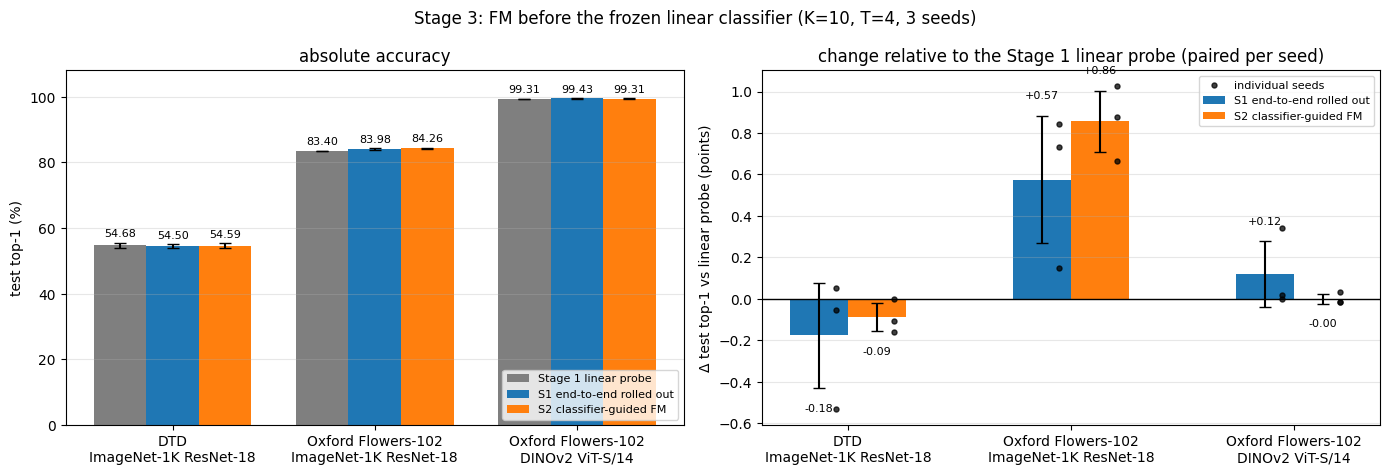

In [ ]:
labels = [f"{DATASETS[ds]['name']}\n{ENCODERS[enc]['name']}" for ds, enc in stage3]
x = np.arange(len(labels))
width = 0.26
series = (('baseline', 'Stage 1 linear probe', 'tab:gray'),
          ('s1', 'S1 end-to-end rolled out', 'tab:blue'),
          ('s2', 'S2 classifier-guided FM', 'tab:orange'))

fig, (axL, axR) = plt.subplots(1, 2, figsize=(14, 4.8))

for i, (key, label, col) in enumerate(series):
    means = [ms(acc[key])[0] for acc in stage3.values()]
    stds = [ms(acc[key])[1] for acc in stage3.values()]
    bars = axL.bar(x + (i - 1) * width, means, width, yerr=stds, capsize=4,
                   label=label, color=col)
    axL.bar_label(bars, fmt='%.2f', fontsize=8, padding=3)
axL.set_xticks(x, labels)
axL.set_ylim(0, 108)
axL.set_ylabel('test top-1 (%)')
axL.set_title('absolute accuracy')
axL.legend(fontsize=8, loc='lower right')
axL.grid(axis='y', alpha=0.3)

# The effects are far smaller than the differences between dataset/encoder combinations, so
# the absolute panel cannot show them. Deltas are paired per seed (same subset and the same
# pretrained classifier within a seed), and the error bars are the std of those paired deltas.
for i, (key, label, col) in enumerate(series[1:]):
    d = [100 * (np.array(acc[key]) - np.array(acc['baseline'])) for acc in stage3.values()]
    bars = axR.bar(x + (i - 0.5) * width, [v.mean() for v in d], width,
                   yerr=[v.std() for v in d], capsize=4, label=label, color=col)
    axR.bar_label(bars, fmt='%+.2f', fontsize=8, padding=11)
for j, acc in enumerate(stage3.values()):                      # individual paired runs
    for i, (key, _, _) in enumerate(series[1:]):
        d = 100 * (np.array(acc[key]) - np.array(acc['baseline']))
        # nudged off the bar centre so the dots never sit on the error bar or the value label
        axR.scatter(np.full_like(d, x[j] + (i - 0.5) * width + 0.075), d, s=13, color='k',
                    zorder=4, alpha=0.75,
                    label='individual seeds' if (i == 0 and j == 0) else None)
axR.axhline(0, color='k', lw=1)
axR.set_xticks(x, labels)
axR.set_ylabel('Δ test top-1 vs linear probe (points)')
axR.set_title('change relative to the Stage 1 linear probe (paired per seed)')
axR.legend(fontsize=8)
axR.grid(axis='y', alpha=0.3)

fig.suptitle(f'Stage 3: FM before the frozen linear classifier '
             f'(K={K_SHOT}, T={T_STEPS}, 3 seeds)')
fig.tight_layout()
plt.show()

### Reading the results

**Flowers-102/ResNet-18 : small, consistent gain from both methods.** Classifier guided FM:
$+0.86$ (83.40→84.26); end to end rollout: $+0.58$. Per seed deltas are paired (same
subset/classifier) and all positive: S2 $+0.88/+0.67/+1.02$, S1 $+0.73/+0.15/+0.85$ : small, but
not noise.

**DTD/ResNet-18 : no gain.** $-0.18$ (S1), $-0.09$ (S2), deltas straddling zero. DTD's own
baseline spread across seeds ($\pm0.76$) is 4–8× larger than either effect, because its 10 of 40
subsets genuinely differ per seed. Flowers' 10 shot subset *is* the full split (identical across
seeds), so its spread is only $\pm0.09$, small enough to resolve a sub point effect. The two
datasets aren't equally able to show an effect this size, and only Flowers does.

**Where anything happens, classifier guided targets beat end to end rollout** ($+0.86$ vs
$+0.58$, tighter spread $\pm0.13$ vs $\pm0.25$, no per dataset tuning needed). Strategy 2 never
sees the classification loss directly (only a *bounded* displacement) so it can't chase
training CE to zero the way Strategy 1 can. The implicit constraint beats the extra freedom.

## 9.2 Training behaviour

Representative curves (seed 0), one row per dataset, three panels:

1. **each method's own objective** : CE+displacement (S1) vs. velocity MSE (S2); different
   scales, shown only to confirm stable optimisation.
2. **CE through the frozen classifier** on train/val : directly comparable across methods and to
   baseline (dashed line = identity init).
3. **top 1 accuracy** on train/val, with the selected checkpoint marked.

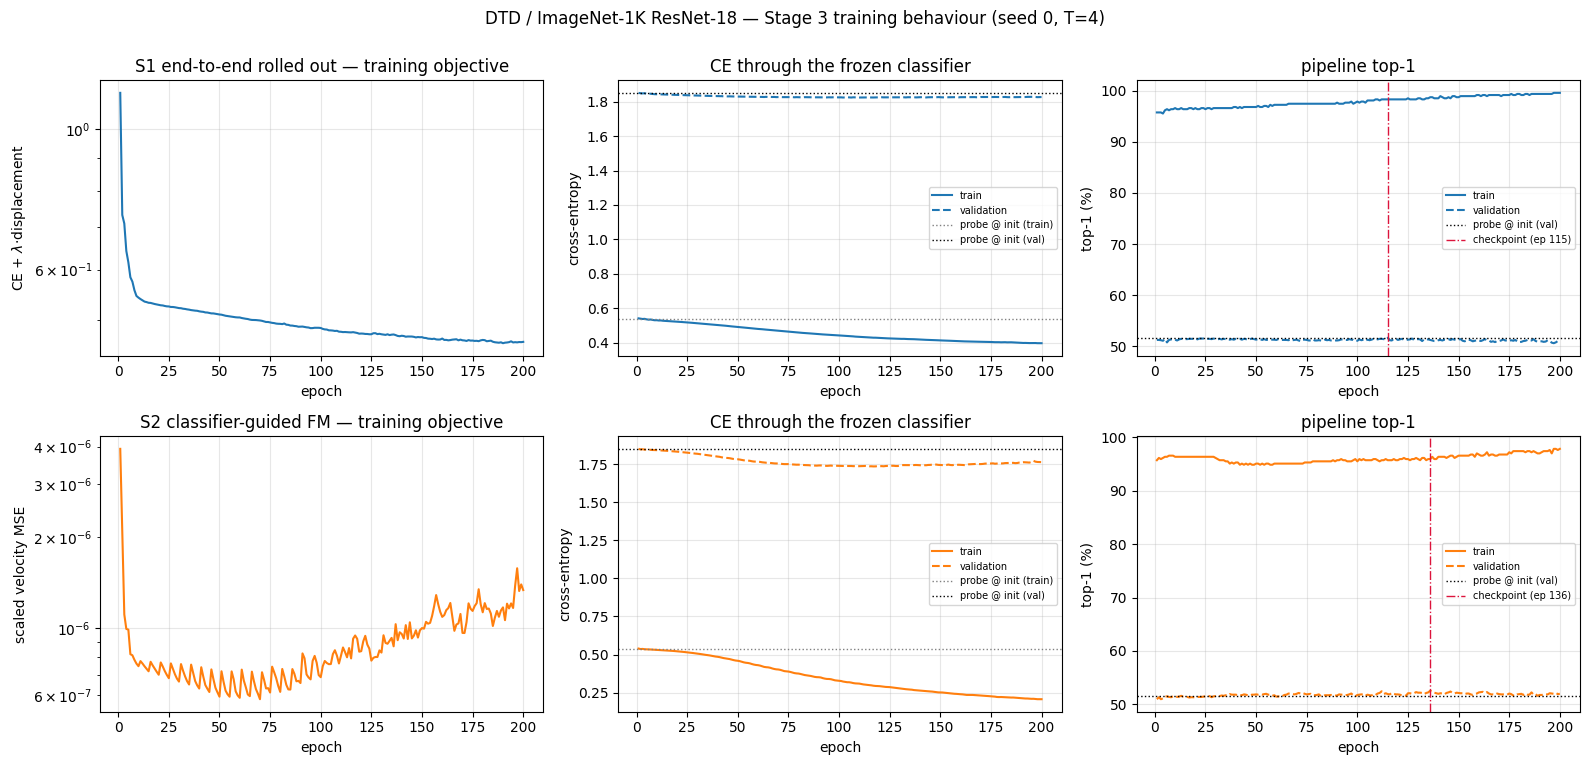

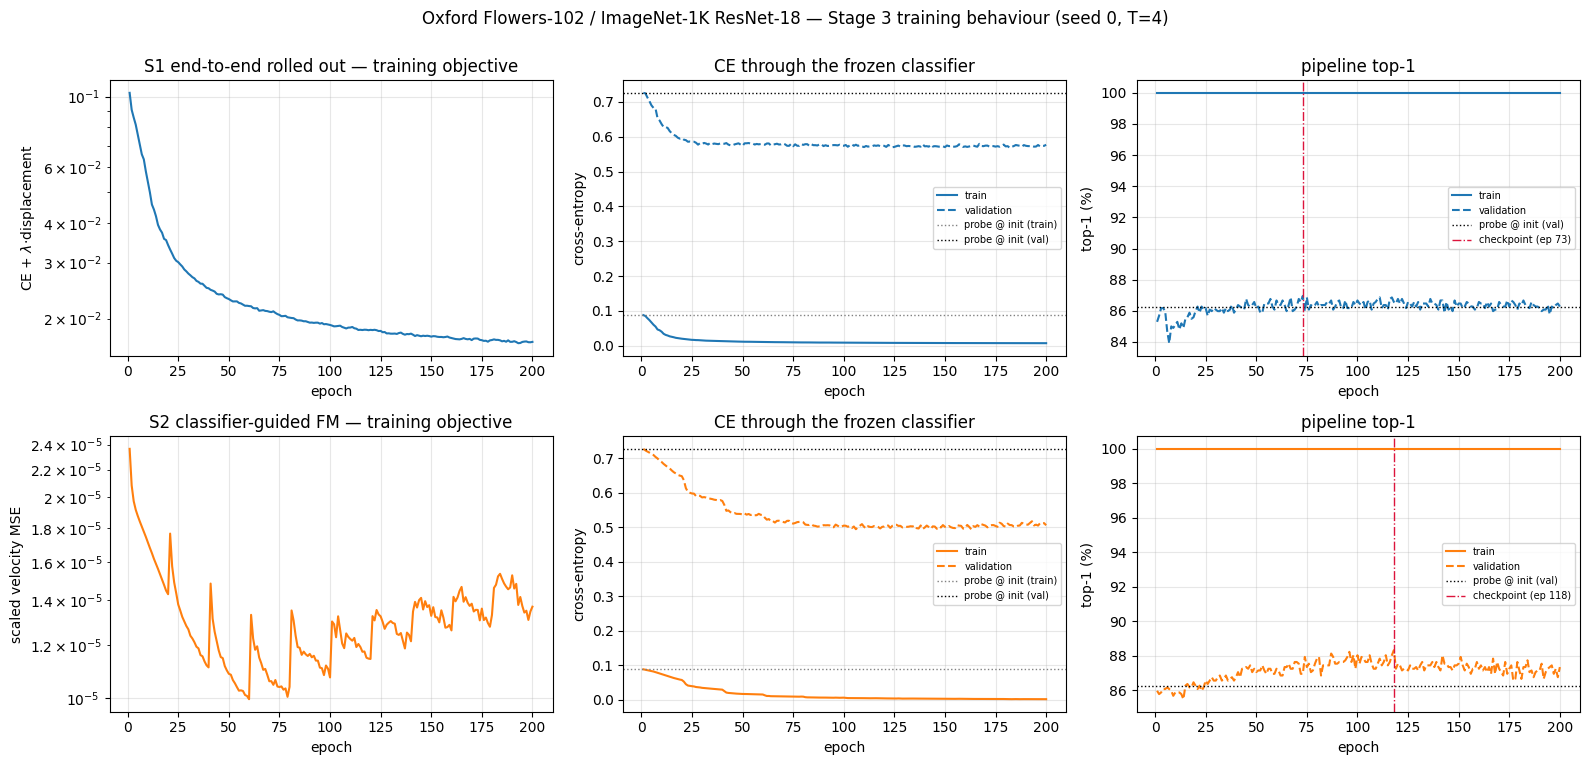

In [ ]:
for (ds, enc) in MAIN_COMBOS:
    r = representative[(ds, enc)]
    bd = r['bundle']
    with torch.no_grad():
        base_tr_ce = F.cross_entropy(bd['clf'](bd['Ztr']), bd['ytr']).item()
        base_va_ce = F.cross_entropy(bd['clf'](bd['Zva']), bd['yva']).item()

    fig, axes = plt.subplots(2, 3, figsize=(16, 7.6))
    for row, (key, name, obj_label, col) in enumerate((
            ('s1', 'S1 end-to-end rolled out', 'CE + $\\lambda$·displacement', 'tab:blue'),
            ('s2', 'S2 classifier-guided FM', 'scaled velocity MSE', 'tab:orange'))):
        h, best = r[f'hist_{key}'], r[f'best_{key}']
        ep = np.arange(1, len(h['objective']) + 1)

        ax = axes[row, 0]
        ax.plot(ep, h['objective'], color=col)
        ax.set_yscale('log'); ax.set_xlabel('epoch'); ax.set_ylabel(obj_label)
        ax.set_title(f'{name} — training objective'); ax.grid(alpha=0.3)

        ax = axes[row, 1]
        ax.plot(ep, h['train_ce'], label='train', color=col)
        ax.plot(ep, h['val_ce'], label='validation', color=col, ls='--')
        ax.axhline(base_tr_ce, color='gray', lw=1, ls=':', label='probe @ init (train)')
        ax.axhline(base_va_ce, color='k', lw=1, ls=':', label='probe @ init (val)')
        ax.set_xlabel('epoch'); ax.set_ylabel('cross-entropy')
        ax.set_title('CE through the frozen classifier'); ax.legend(fontsize=7); ax.grid(alpha=0.3)

        ax = axes[row, 2]
        ax.plot(ep, 100 * np.array(h['train_acc']), label='train', color=col)
        ax.plot(ep, 100 * np.array(h['val_acc']), label='validation', color=col, ls='--')
        ax.axhline(100 * bd['base_val'], color='k', lw=1, ls=':', label='probe @ init (val)')
        ax.axvline(best['epoch'] + 1, color='crimson', lw=1, ls='-.',
                   label=f"checkpoint (ep {best['epoch']+1})")
        ax.set_xlabel('epoch'); ax.set_ylabel('top-1 (%)')
        ax.set_title('pipeline top-1'); ax.legend(fontsize=7); ax.grid(alpha=0.3)

    fig.suptitle(f"{DATASETS[ds]['name']} / {ENCODERS[enc]['name']} — "
                 f"Stage 3 training behaviour (seed 0, T={T_STEPS})", y=1.0)
    fig.tight_layout()
    plt.show()

### Reading the curves

**Both methods optimise stably.** S1's objective falls smoothly, ~1 order of magnitude on both
datasets. S2's velocity MSE shows a **sawtooth** matching the target refresh period $R$
(5 epochs DTD, 20 Flowers): loss falls within a block as the network fits fixed targets, then
jumps at each refresh as targets move. DTD's slow upward drift after ~epoch 75 is this
compounding, targets keep receding. Expected for a moving target objective, not instability.

**The middle column (CE) is where Stage 3 succeeds or fails.** Both methods drive *training* CE
well below the frozen probe's starting value (DTD 0.54→0.43/0.27; Flowers 0.09→0.010/0.005),
doing exactly what they're trained to do. Whether it transfers differs by dataset:

* **Flowers**: validation CE also drops substantially (0.73→0.58/0.50), validation top-1 rises
  86.27%→86.96%/88.33% — a genuine, generalising rearrangement.
* **DTD**: validation CE barely moves (1.85→~1.78), validation top 1 stays ~51–52% while
  training top 1 climbs to ~99.5% — almost pure memorisation.

DTD's checkpoint markers show the consequence: on a flat, noisy validation curve, "highest
validation accuracy" selects sampling noise (epoch 115/136), which is why DTD's test numbers in
9.1 wobble around zero rather than sitting on it. This is also the best argument *for*
validation based checkpointing, without it, DTD would return the fully memorised final epoch
and look much worse.

### How far does the flow actually move the features?

Displacement $\mathbb{E}\lVert \hat z-z\rVert/\lVert z\rVert$ on the test split, plus pipeline
CE/accuracy before (identity) and after training.

In [ ]:
rows = []
for (ds, enc), r in representative.items():
    bd = r['bundle']
    with torch.no_grad():
        base_ce = F.cross_entropy(bd['clf'](bd['Zte']), bd['yte']).item()
    for key, name in (('s1', 'S1 end-to-end'), ('s2', 'S2 classifier-guided')):
        m = r[f'model_{key}']
        ce, acc = pipeline_metrics(m, bd['Zte'], bd['yte'], bd['clf'])
        tr_ce, tr_acc = pipeline_metrics(m, bd['Ztr'], bd['ytr'], bd['clf'])
        rows.append({'dataset': DATASETS[ds]['name'], 'encoder': enc, 'method': name,
                     'rel. displacement (test)': f"{mean_rel_displacement(m, bd['Zte']):.3f}",
                     'train CE': f'{tr_ce:.3f}', 'train top-1': f'{100*tr_acc:.1f}',
                     'test CE @ init': f'{base_ce:.3f}', 'test CE': f'{ce:.3f}',
                     'test top-1 @ init': f"{100*bd['base_test']:.2f}",
                     'test top-1': f'{100*acc:.2f}'})
display(pd.DataFrame(rows).style.hide(axis='index'))

dataset,encoder,method,rel. displacement (test),train CE,train top-1,test CE @ init,test CE,test top-1 @ init,test top-1
DTD,resnet18,S1 end-to-end,0.028,0.431,98.3,1.769,1.747,53.72,53.78
DTD,resnet18,S2 classifier-guided,0.152,0.269,96.0,1.769,1.651,53.72,53.62
Oxford Flowers-102,resnet18,S1 end-to-end,0.108,0.010,100.0,0.802,0.658,83.28,84.01
Oxford Flowers-102,resnet18,S2 classifier-guided,0.229,0.005,100.0,0.802,0.602,83.28,84.16
Oxford Flowers-102,dinov2,S1 end-to-end,0.064,0.014,100.0,0.096,0.073,99.40,99.41
Oxford Flowers-102,dinov2,S2 classifier-guided,0.021,0.026,100.0,0.096,0.096,99.40,99.38


### Reading the displacement diagnostic

The flow is a **small targeted correction, not a re embedding**: selected models move test
features by 2.8% (DTD S1), 15.2% (DTD S2), 10.8% (Flowers S1), 22.9% (Flowers S2) of their
norm, still much closer to $z$ than to any other class.

**Test CE improves everywhere, including where accuracy doesn't.** DTD: 1.769→1.747/1.651;
Flowers: 0.802→0.658/0.602. On DTD the flow generalises *something*, more confident on unseen
data, but never enough to flip a decision. A 6.7% CE drop alongside a $-0.09$-point accuracy
change is loss/accuracy decoupling, echoing the Stage 2 follow up checks.

**Displacement size doesn't predict accuracy gain.** The largest mover (Flowers S2, 22.9%) is
the best method, but the second largest (DTD S2, 15.2%) gains nothing, and DINOv2 moves only
6.4%/2.1% for ±0.1pt. What matters isn't distance travelled but whether the direction reflects a
property of the *encoder* or just the 10 shot *sample*.

## 9.3 Feature space visualisation

Original $z$ vs. transported $\hat z$ (both Stage 3 methods) for 10 readable classes : same test
examples/colours, 2D embedding fit **jointly** over all three sets. Both PCA (preserves global
geometry, shows *how far* things moved) and joint t-SNE (more readable for entangled DTD
features) are shown.

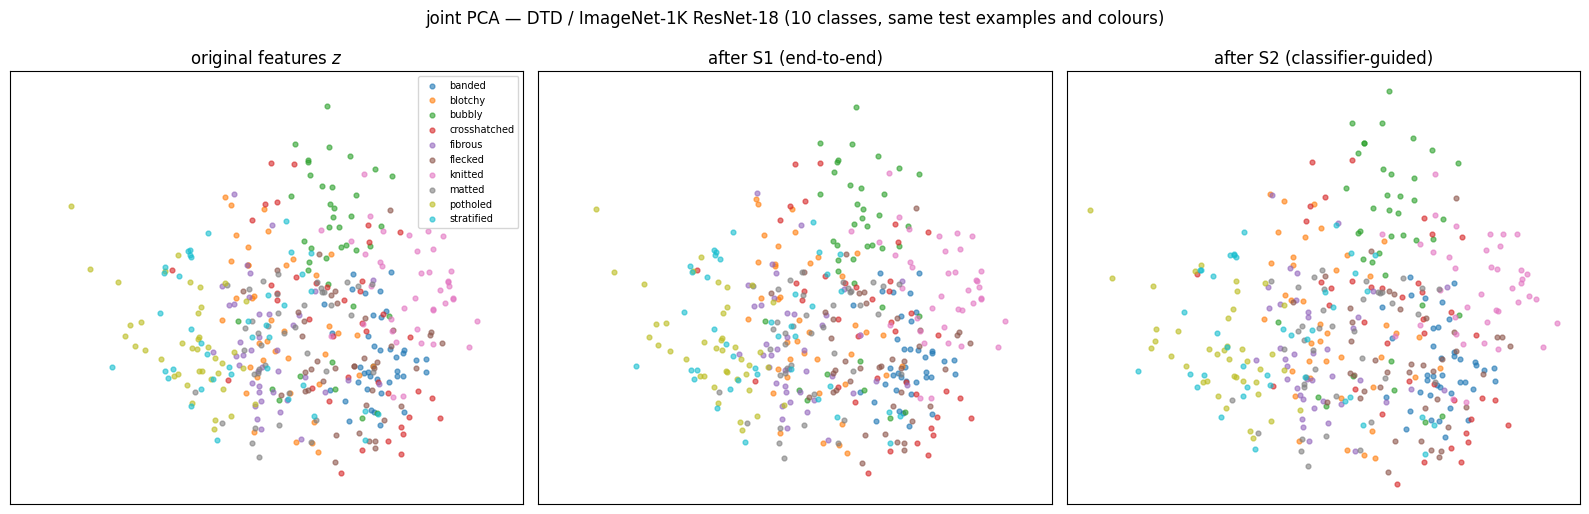

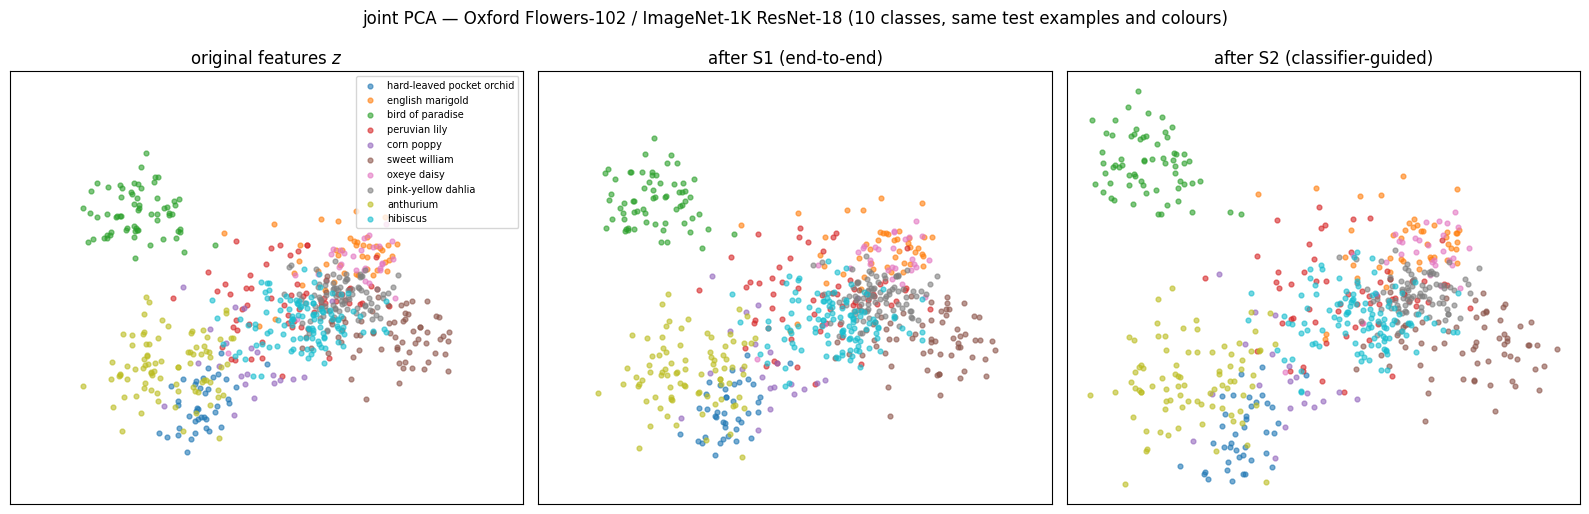

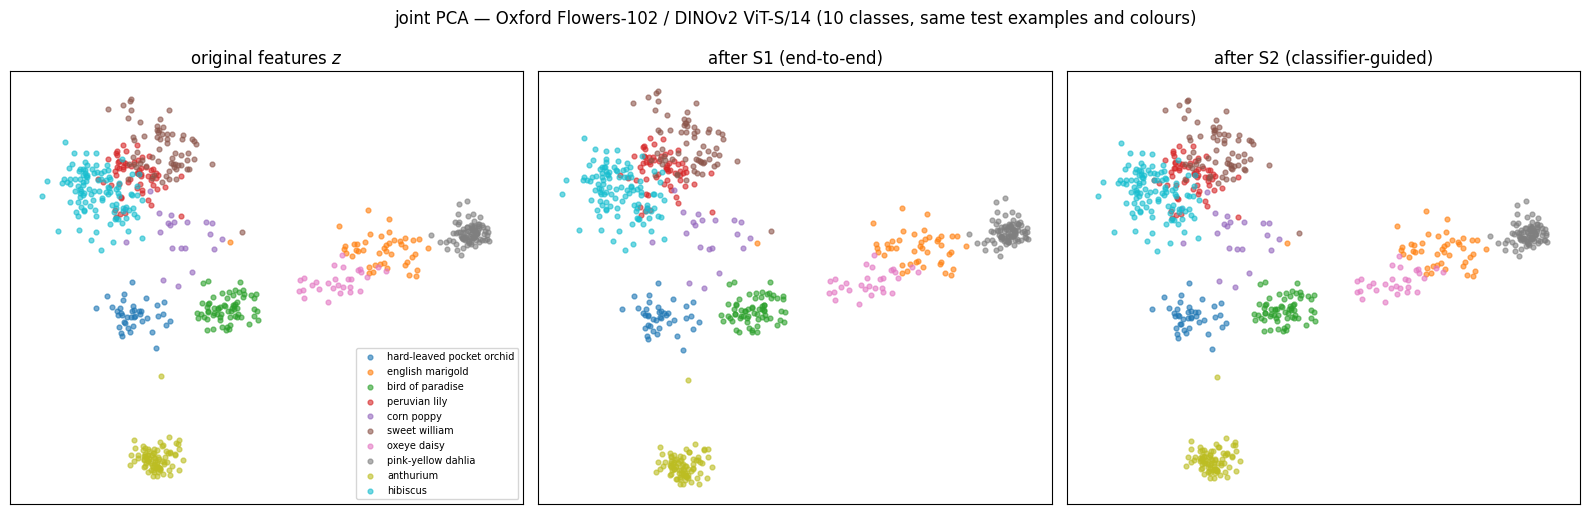

In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

N_SHOW = 10
viz_cache = {}

for (ds, enc), r in representative.items():
    cfg, bd = DATASETS[ds], r['bundle']
    rng = np.random.default_rng(0)                     # same class subset as Stages 1-2
    class_ids = sorted(rng.choice(cfg['num_classes'], size=N_SHOW, replace=False).tolist())
    names = load_class_names(ds)

    mask = np.isin(bd['yte_np'], class_ids)
    Z0 = bd['Zte'].cpu().numpy()[mask]
    y_sub = bd['yte_np'][mask]
    Z1 = transport(r['model_s1'], Z0)
    Z2 = transport(r['model_s2'], Z0)
    viz_cache[(ds, enc)] = dict(class_ids=class_ids, names=names, y_sub=y_sub,
                                sets=[Z0, Z1, Z2])

titles = ['original features $z$', 'after S1 (end-to-end)', 'after S2 (classifier-guided)']


def joint_panels(reducer_name):
    for (ds, enc), v in viz_cache.items():
        stacked = np.vstack(v['sets'])
        if reducer_name == 'PCA':
            proj = PCA(n_components=2, random_state=0).fit_transform(stacked)
        else:
            proj = TSNE(n_components=2, random_state=0, init='pca',
                        perplexity=30).fit_transform(stacked)
        n = len(v['sets'][0])
        parts = [proj[i * n:(i + 1) * n] for i in range(3)]

        fig, axes = plt.subplots(1, 3, figsize=(16, 5.2), sharex=True, sharey=True)
        cmap = plt.get_cmap('tab10')
        for ax, pts, title in zip(axes, parts, titles):
            for i, c in enumerate(v['class_ids']):
                m = v['y_sub'] == c
                ax.scatter(pts[m, 0], pts[m, 1], s=12, color=cmap(i % 10), alpha=0.6,
                           label=(v['names'][c] if v['names'] else f'class {c}')
                           if title == titles[0] else None)
            ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
        axes[0].legend(fontsize=7, loc='best')
        fig.suptitle(f"joint {reducer_name} — {DATASETS[ds]['name']} / {ENCODERS[enc]['name']} "
                     f"({N_SHOW} classes, same test examples and colours)")
        fig.tight_layout()
        plt.show()


joint_panels('PCA')

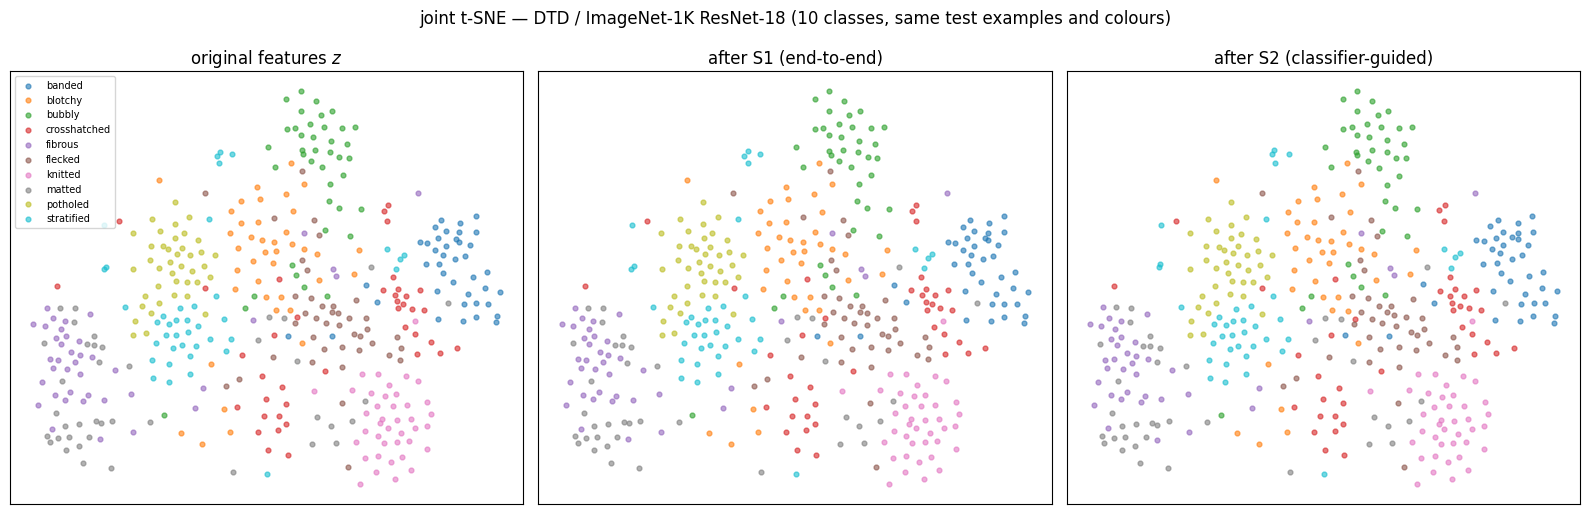

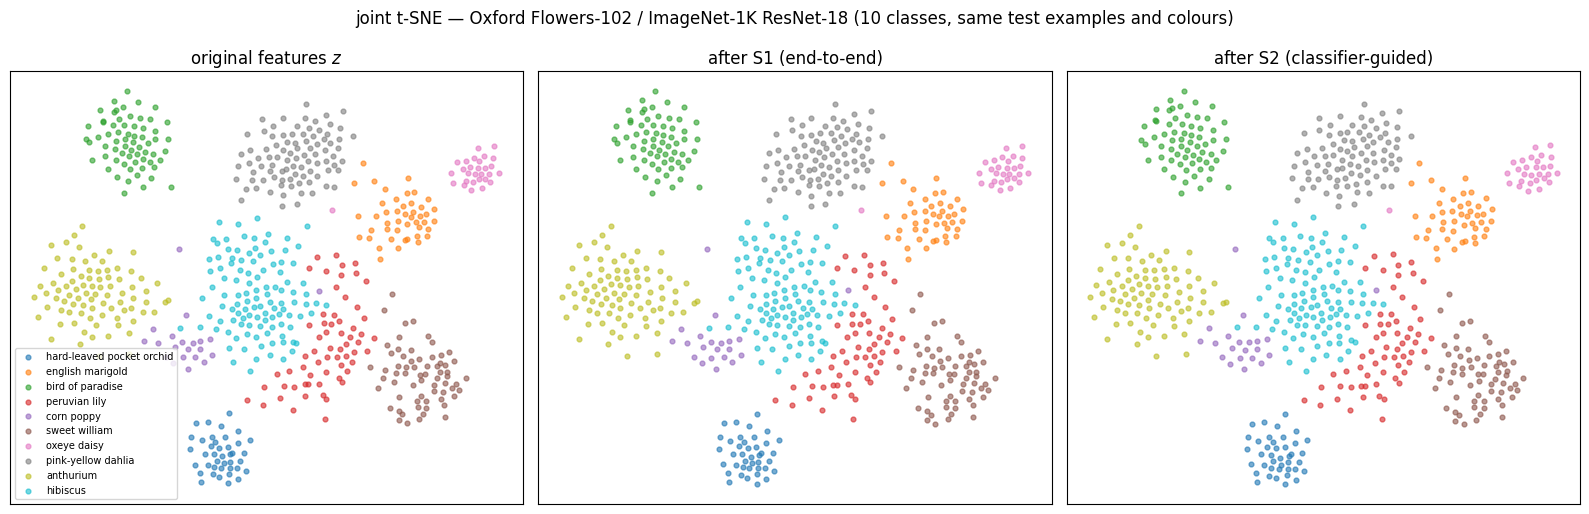

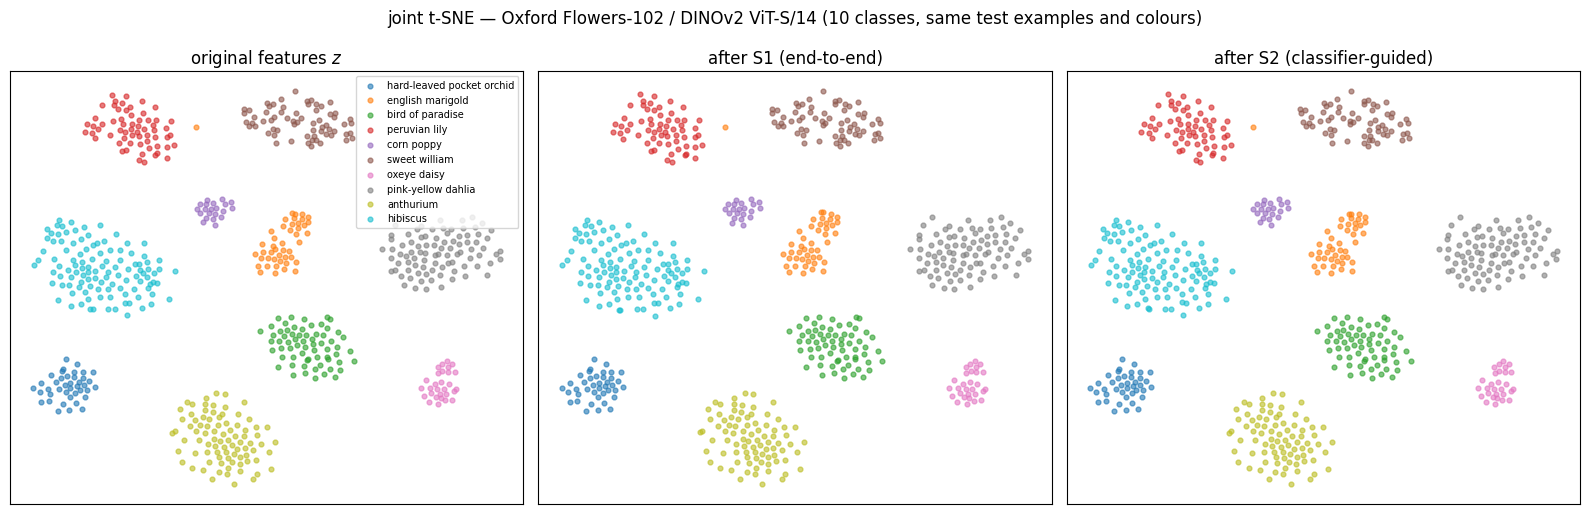

In [ ]:
joint_panels('t-SNE')

### Where does the flow actually push each feature?

Since $\hat z$ stays close to $z$, side by side panels understate the transport. The same joint
PCA coordinates are reused to draw the displacement $z\to\hat z$ as an arrow per example
(60 random per panel, for legibility).

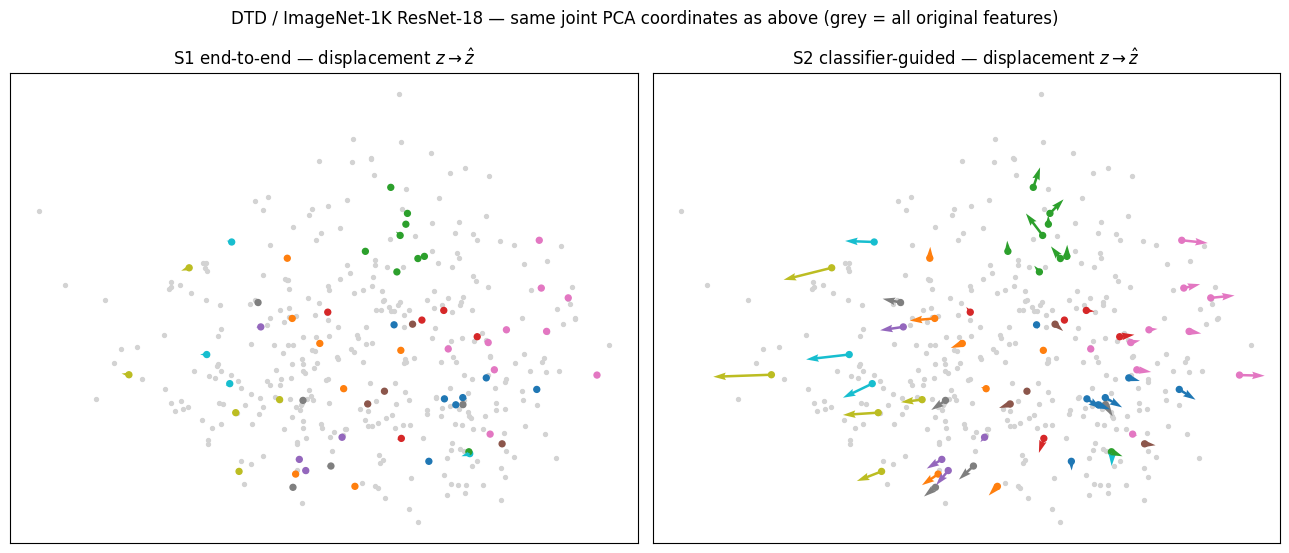

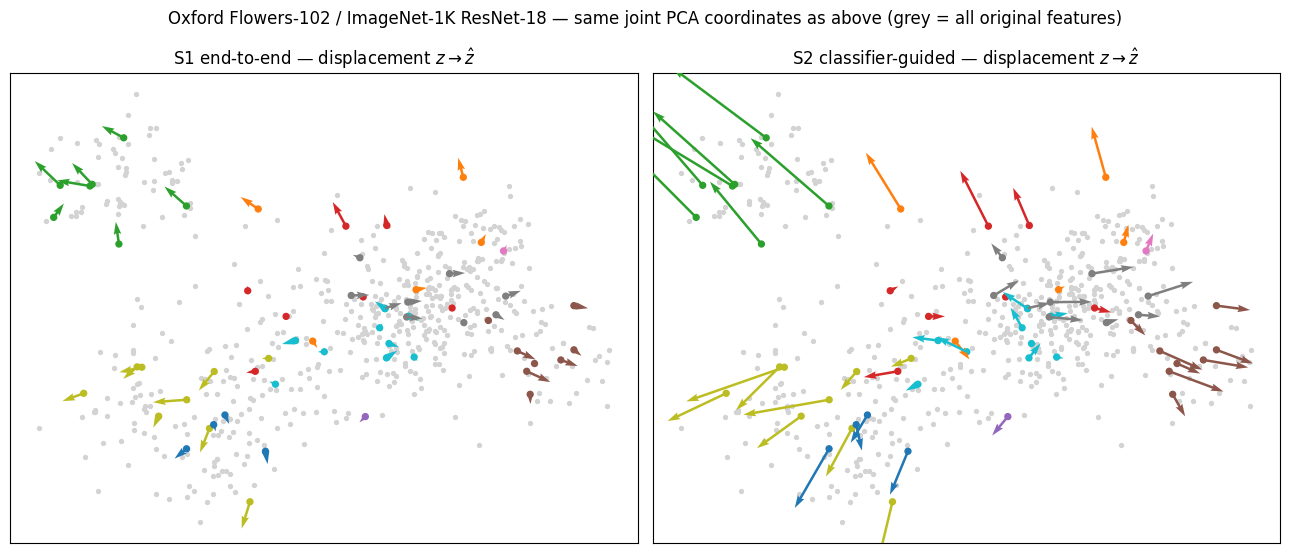

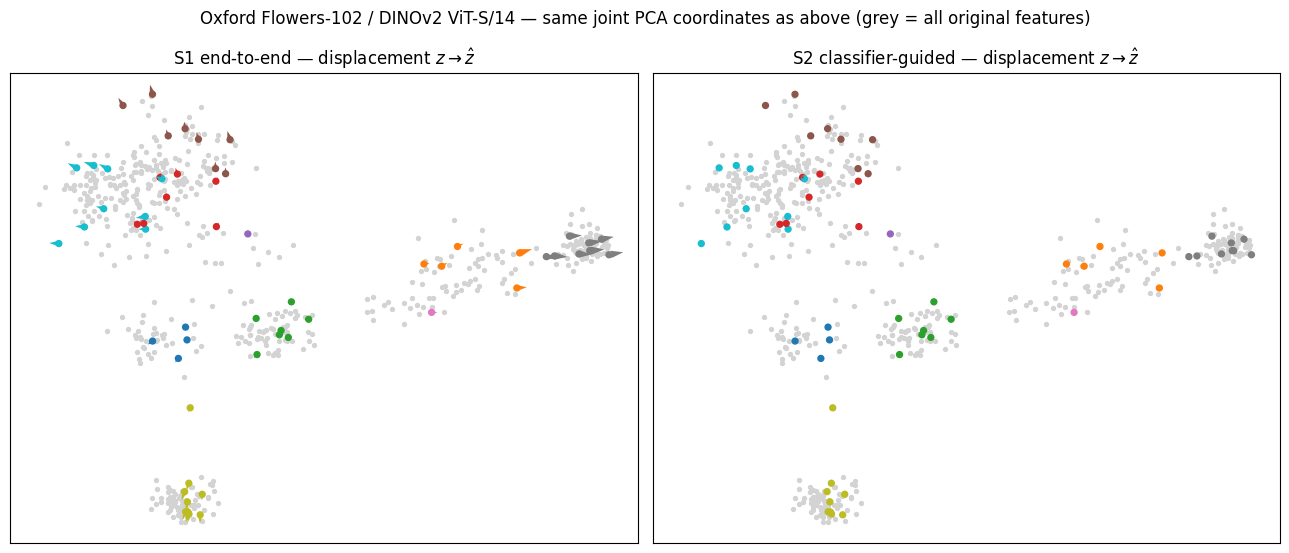

In [ ]:
N_ARROWS = 60

for (ds, enc), v in viz_cache.items():
    stacked = np.vstack(v['sets'])
    proj = PCA(n_components=2, random_state=0).fit_transform(stacked)
    n = len(v['sets'][0])
    p_orig, p_s1, p_s2 = proj[:n], proj[n:2 * n], proj[2 * n:]

    rng = np.random.default_rng(3)
    pick = rng.choice(n, size=min(N_ARROWS, n), replace=False)
    cmap = plt.get_cmap('tab10')
    colours = np.array([cmap(v['class_ids'].index(c) % 10) for c in v['y_sub'][pick]])

    fig, axes = plt.subplots(1, 2, figsize=(13, 5.6), sharex=True, sharey=True)
    for ax, p_end, title in ((axes[0], p_s1, 'S1 end-to-end'),
                             (axes[1], p_s2, 'S2 classifier-guided')):
        ax.scatter(p_orig[:, 0], p_orig[:, 1], s=8, color='lightgray', zorder=1)
        start, end = p_orig[pick], p_end[pick]
        ax.quiver(start[:, 0], start[:, 1], end[:, 0] - start[:, 0], end[:, 1] - start[:, 1],
                  color=colours, angles='xy', scale_units='xy', scale=1,
                  width=0.004, zorder=3)
        ax.scatter(start[:, 0], start[:, 1], s=18, color=colours, zorder=2)
        ax.set_title(f'{title} — displacement $z \\rightarrow \\hat z$')
        ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle(f"{DATASETS[ds]['name']} / {ENCODERS[enc]['name']} — same joint PCA "
                 f"coordinates as above (grey = all original features)")
    fig.tight_layout()
    plt.show()

### A quantitative counterpart to the pictures

2D projections are qualitative, so separability is also measured directly in full feature
space, on the test split:

* **logit margin**: mean(correct class logit − best competitor) : signed distance to the
  decision boundary.
* **within/between scatter ratio**: within class variance / between class mean variance
  (lower = more separable).
* **cosine to own class weight vector**: mean $\cos(\hat z, W_{:,y})$ : alignment with how the
  classifier scores the feature.

In [ ]:
def separability(Z, y, clf):
    Zt_ = torch.as_tensor(Z, dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        logits = clf(Zt_)
        true = logits.gather(1, torch.as_tensor(y, device=DEVICE).view(-1, 1)).squeeze(1)
        other = logits.clone()
        other.scatter_(1, torch.as_tensor(y, device=DEVICE).view(-1, 1), -float('inf'))
        margin = float((true - other.max(1).values).mean())
        wvec = clf.W.T[torch.as_tensor(y, device=DEVICE)]
        cos = float(F.cosine_similarity(Zt_, wvec, dim=1).mean())
    Zn = np.asarray(Z, dtype=np.float64)
    means = np.stack([Zn[y == c].mean(0) for c in np.unique(y)])
    within = np.mean([Zn[y == c].var(0).sum() for c in np.unique(y)])
    between = means.var(0).sum()
    return margin, within / max(between, 1e-12), cos


rows = []
for (ds, enc), r in representative.items():
    bd = r['bundle']
    Zte_np, yte_np = bd['Zte'].cpu().numpy(), bd['yte_np']
    sets = [('original $z$ (= Stage 1 probe)', Zte_np),
            ('after S1 end-to-end', transport(r['model_s1'], Zte_np)),
            ('after S2 classifier-guided', transport(r['model_s2'], Zte_np))]
    for name, Z in sets:
        margin, ratio, cos = separability(Z, yte_np, bd['clf'])
        rows.append({'dataset': DATASETS[ds]['name'], 'encoder': enc, 'features': name,
                     'logit margin': f'{margin:+.3f}',
                     'within/between scatter': f'{ratio:.3f}',
                     'cos(z, W_y)': f'{cos:.4f}',
                     'test top-1': f'{100*top1_accuracy(yte_np, (Z @ bd["probe"].W + bd["probe"].b).argmax(1)):.2f}'})
display(pd.DataFrame(rows).style.hide(axis='index'))

dataset,encoder,features,logit margin,within/between scatter,"cos(z, W_y)",test top-1
DTD,resnet18,original $z$ (= Stage 1 probe),+0.178,3.345,-0.0264,53.72
DTD,resnet18,after S1 end-to-end,+0.182,3.317,-0.0206,53.78
DTD,resnet18,after S2 classifier-guided,+0.475,2.895,0.0354,53.62
Oxford Flowers-102,resnet18,original $z$ (= Stage 1 probe),+2.043,1.593,-0.0035,83.28
Oxford Flowers-102,resnet18,after S1 end-to-end,+2.667,1.535,0.0343,84.01
Oxford Flowers-102,resnet18,after S2 classifier-guided,+4.047,1.381,0.0959,84.16
Oxford Flowers-102,dinov2,original $z$ (= Stage 1 probe),+4.610,0.468,0.5098,99.40
Oxford Flowers-102,dinov2,after S1 end-to-end,+5.075,0.454,0.5305,99.41
Oxford Flowers-102,dinov2,after S2 classifier-guided,+4.644,0.465,0.5118,99.38


### Reading the visualisations

**Class structure is essentially preserved.** In the joint PCA, all three panels share one
coordinate system and clusters keep their identity: on Flowers the ten clusters stay in place
with the same shapes, with a mild outward stretch/tightening (strongest for S2). On DTD, all
three panels are the same crowded, entangled blob, consistent with its ~0% improvement.

**The joint t-SNE panels look nearly identical, and that itself is the measurement.** Since $z$
and its $\hat z$ are near duplicate points in the joint embedding, panels can only differ if the
flow moves a feature far enough to change its neighbourhood. They barely do, bounding
displacement well below inter class distance, matching both the displacement table and Stage 2's
short trajectory finding.

**The arrow plots show what the panels hide.** Displacements aren't random : arrows within a
class point in a common direction, i.e. a *class conditional* correction, not per sample noise.
Lengths match the displacement table exactly: S2 arrows are clearly longer than S1 on both
ResNet-18 combinations (DTD 0.152 vs 0.028; Flowers 0.229 vs 0.108), DTD's S1 arrows are barely
visible, which is what $\lambda=100$ buys. On DINOv2 the ordering reverses and both are
near invisible (0.064 vs 0.021). S2 there is essentially the identity map (epoch-0 checkpoint).

**The numeric table shows what 2D can't.** On the test split : **logit margin** grows sharply
under S2 : DTD 0.178→0.475 (2.7×), Flowers 2.043→4.047 (2.0×). **scatter ratio** falls in every
case (DTD 3.345→2.895, Flowers 1.593→1.381) : classes get more compact relative to separation.
**cosine to class weight** rises from ≈0 to $+0.035$ (DTD S2) / $+0.096$ (Flowers S2) : features
rotate toward their own class direction.

DTD is the sharp case : margin up 2.7×, scatter down, test CE down 6.7%, yet accuracy $-0.09$.
These are averages dominated by already correct samples: the flow makes confident predictions
more confident without flipping boundary cases. Improving the geometry the classifier measures
is necessary but not sufficient for accuracy.

## 9.4 Saturation check : DINOv2 on Flowers-102

The main comparison uses ResNet-18 on both datasets. As a control, both Stage 3 methods are also
applied to Flowers/DINOv2 (reusing the Flowers/ResNet-18 configuration, no separate tuning).
its linear probe is already ~99%, leaving essentially no headroom.

In [ ]:
ds, enc = SATURATION_COMBO
acc = stage3[(ds, enc)]
bm, bs = ms(acc['baseline'])
sat = [{'method': 'Stage 1 linear probe', 'test top-1': f'{bm:.2f} ± {bs:.2f}', 'Δ': '—'}]
for key, label in (('s1', 'S1 end-to-end rolled out'), ('s2', 'S2 classifier-guided FM')):
    m, s = ms(acc[key])
    sat.append({'method': label, 'test top-1': f'{m:.2f} ± {s:.2f}', 'Δ': f'{m-bm:+.2f}'})
print(f"{DATASETS[ds]['name']} / {ENCODERS[enc]['name']}  (K={K_SHOT}, T={T_STEPS}, 3 seeds)")
display(pd.DataFrame(sat).style.hide(axis='index'))

r = representative[(ds, enc)]
bd = r['bundle']
for key, name in (('s1', 'S1'), ('s2', 'S2')):
    print(f"  {name}: rel. displacement {mean_rel_displacement(r[f'model_{key}'], bd['Zte']):.3f}"
          f", checkpoint epoch {r[f'best_{key}']['epoch']}")

Oxford Flowers-102 / DINOv2 ViT-S/14  (K=10, T=4, 3 seeds)


method,test top-1,Δ
Stage 1 linear probe,99.31 ± 0.11,—
S1 end-to-end rolled out,99.43 ± 0.05,+0.12
S2 classifier-guided FM,99.31 ± 0.12,-0.00


  S1: rel. displacement 0.064, checkpoint epoch 7
  S2: rel. displacement 0.021, checkpoint epoch 0


### Reading the saturation check

DINOv2's linear probe is already 99.31% (≈42/6149 test images wrong); Stage 3 changes it by
$+0.12$ (S1) and $-0.00$ (S2), both inside the $\pm0.11$ baseline seed spread. S2 stops at
epoch 0 on all three seeds (2.1% displacement), essentially the identity map, since validation
is never beaten.

Its separability numbers explain why: $\cos(z,W_{:,y})=0.51$ (vs. ≈0 for ResNet-18), scatter
ratio 0.47 (vs. 1.59), DINOv2's features are already aligned with the classifier, so there's
nothing to fix.

This is the key control for the main result : **FM before a frozen classifier helps only when the
representation is misaligned *and* there's enough data to identify the misalignment.** It also
justifies the Part 2 encoder choice : on DINOv2/Flowers, every method would read ~99.3% and the
experiment would measure nothing.

---
# Part 10 : Optional extension : jointly fine tuning the classifier

FM and the pretrained classifier are now optimised together on the rolled out CE objective, with
a separate smaller classifier learning rate and optional delayed unfreezing. FM keeps the
displacement penalty selected in Part 7.

**Control :** classifier only continued training (no FM, just resumed AdamW on $(W,b)$ from the
Stage 1 checkpoint), if joint fine tuning doesn't beat this, FM is contributing nothing.

In [ ]:
def train_joint(bundle, lam_disp, lr_fm=FM_LR, lr_clf=1e-4, unfreeze_at=0,
                epochs=FM_EPOCHS, batch_size=FM_BATCH, T=T_STEPS, use_fm=True, seed=None):
    """Optional extension: FM + trainable copy of the Stage 1 classifier."""
    seed = bundle['seed'] if seed is None else seed
    torch.manual_seed(seed)
    Ztr, ytr, s = bundle['Ztr'], bundle['ytr'], bundle['scale']
    W = bundle['clf'].W.clone().requires_grad_(True)
    b = bundle['clf'].b.clone().requires_grad_(True)
    live = lambda z: z @ W + b

    model = VelocityMLP(bundle['dim'], scale=s).to(DEVICE)
    opt_fm = torch.optim.Adam(model.parameters(), lr=lr_fm)
    opt_clf = torch.optim.AdamW([W, b], lr=lr_clf,
                                weight_decay=LINEAR_PROBE['weight_decay'])

    n = Ztr.shape[0]
    bs = min(batch_size, n)
    hist = {'objective': [], 'val_acc': [], 'train_acc': []}
    best = {'val_acc': -1.0, 'epoch': -1, 'state': None}

    for ep in range(epochs):
        clf_live = ep >= unfreeze_at
        perm = torch.randperm(n, device=DEVICE)
        running = 0.0
        for start in range(0, n, bs):
            idx = perm[start:start + bs]
            z0 = Ztr[idx]
            z_hat = fm_rollout(model, z0, T) if use_fm else z0
            loss = F.cross_entropy(live(z_hat), ytr[idx])
            if use_fm and lam_disp > 0:
                loss = loss + lam_disp * ((z_hat - z0) / s).pow(2).sum(1).mean()
            opt_fm.zero_grad(); opt_clf.zero_grad()
            loss.backward()
            if use_fm:
                opt_fm.step()
            if clf_live:
                opt_clf.step()
            running += loss.item() * len(idx)

        with torch.no_grad():
            zv = fm_rollout(model, bundle['Zva'], T) if use_fm else bundle['Zva']
            va = float((live(zv).argmax(1) == bundle['yva']).float().mean())
            zt = fm_rollout(model, Ztr, T) if use_fm else Ztr
            tr = float((live(zt).argmax(1) == ytr).float().mean())
        hist['objective'].append(running / n)
        hist['val_acc'].append(va); hist['train_acc'].append(tr)
        if va > best['val_acc']:
            best = {'val_acc': va, 'epoch': ep,
                    'state': ({k: v.detach().clone() for k, v in model.state_dict().items()},
                              W.detach().clone(), b.detach().clone())}

    sd, Wb, bb = best['state']
    model.load_state_dict(sd)
    frozen = FrozenLinear(Wb.cpu().numpy(), bb.cpu().numpy())
    with torch.no_grad():
        zs = fm_rollout(model, bundle['Zte'], T) if use_fm else bundle['Zte']
        te = float((frozen(zs).argmax(1) == bundle['yte']).float().mean())
    return {'model': model, 'clf': frozen, 'hist': hist, 'best': best, 'test_acc': te}


JOINT_GRID = [{'lr_clf': lr, 'unfreeze_at': uf} for lr in (1e-4, 1e-3) for uf in (0, 50)]

joint_rows, joint_pick = [], {}
for ds, enc in MAIN_COMBOS:
    bd = baseline_bundles[(ds, enc, 0)]
    lam = SELECTED[(ds, enc, 'S1')]['lam_disp']
    print(f"\n=== {DATASETS[ds]['name']} / {enc}  (baseline test {bd['base_test']*100:.2f}) ===")

    ctrl = train_joint(bd, lam_disp=0.0, use_fm=False, lr_clf=1e-4)
    joint_rows.append({'dataset': DATASETS[ds]['name'], 'setting': 'control: classifier only, no FM',
                       'val top-1': 100 * ctrl['best']['val_acc'],
                       'test top-1': 100 * ctrl['test_acc'],
                       'test delta': 100 * (ctrl['test_acc'] - bd['base_test'])})
    print(f"  control (classifier only)      val={ctrl['best']['val_acc']*100:.2f} "
          f"test={ctrl['test_acc']*100:.2f} ({100*(ctrl['test_acc']-bd['base_test']):+.2f})")

    trials = {}
    for cfg in JOINT_GRID:
        t0 = time.time()
        out = train_joint(bd, lam_disp=lam, **cfg)
        trials[tuple(sorted(cfg.items()))] = (cfg, out)
        joint_rows.append({'dataset': DATASETS[ds]['name'],
                           'setting': f"joint FM+clf, lr_clf={cfg['lr_clf']:g}, "
                                      f"unfreeze@{cfg['unfreeze_at']}",
                           'val top-1': 100 * out['best']['val_acc'],
                           'test top-1': 100 * out['test_acc'],
                           'test delta': 100 * (out['test_acc'] - bd['base_test'])})
        print(f"  joint lr_clf={cfg['lr_clf']:<7g} unfreeze@{cfg['unfreeze_at']:<3d} "
              f"val={out['best']['val_acc']*100:.2f} test={out['test_acc']*100:.2f} "
              f"({100*(out['test_acc']-bd['base_test']):+.2f}) [{time.time()-t0:.0f}s]")
    pick = max(trials, key=lambda k: trials[k][1]['best']['val_acc'])
    joint_pick[(ds, enc)] = trials[pick]
    print(f'  -> selected {trials[pick][0]}')

joint_table = pd.DataFrame(joint_rows)
display(joint_table.style.format({'val top-1': '{:.2f}', 'test top-1': '{:.2f}',
                                  'test delta': '{:+.2f}'}).hide(axis='index'))


=== DTD / resnet18  (baseline test 53.72) ===


  control (classifier only)      val=51.38 test=53.99 (+0.27)


  joint lr_clf=0.0001  unfreeze@0   val=51.38 test=53.88 (+0.16) [15s]


  joint lr_clf=0.0001  unfreeze@50  val=51.60 test=53.72 (+0.00) [14s]


  joint lr_clf=0.001   unfreeze@0   val=51.44 test=53.67 (-0.05) [16s]


...

  joint lr_clf=0.0001  unfreeze@0   val=87.55 test=84.11 (+0.83) [25s]


  joint lr_clf=0.0001  unfreeze@50  val=87.65 test=84.05 (+0.76) [25s]


  joint lr_clf=0.001   unfreeze@0   val=87.25 test=83.85 (+0.57) [25s]


  joint lr_clf=0.001   unfreeze@50  val=87.35 test=84.01 (+0.73) [25s]
  -> selected {'lr_clf': 0.0001, 'unfreeze_at': 50}


dataset,setting,val top-1,test top-1,test delta
DTD,"control: classifier only, no FM",51.38,53.99,+0.27
DTD,"joint FM+clf, lr_clf=0.0001, unfreeze@0",51.38,53.88,+0.16
DTD,"joint FM+clf, lr_clf=0.0001, unfreeze@50",51.60,53.72,+0.00
DTD,"joint FM+clf, lr_clf=0.001, unfreeze@0",51.44,53.67,-0.05
DTD,"joint FM+clf, lr_clf=0.001, unfreeze@50",51.60,53.72,+0.00
Oxford Flowers-102,"control: classifier only, no FM",86.37,83.35,+0.07
Oxford Flowers-102,"joint FM+clf, lr_clf=0.0001, unfreeze@0",87.55,84.11,+0.83
Oxford Flowers-102,"joint FM+clf, lr_clf=0.0001, unfreeze@50",87.65,84.05,+0.76
Oxford Flowers-102,"joint FM+clf, lr_clf=0.001, unfreeze@0",87.25,83.85,+0.57
Oxford Flowers-102,"joint FM+clf, lr_clf=0.001, unfreeze@50",87.35,84.01,+0.73


In [ ]:
# The joint runs use seed 0 only, so every column here is the seed-0 number: comparing
# against the 3-seed mean would mix a single run with an average.
rows = []
for ds, enc in MAIN_COMBOS:
    acc = stage3[(ds, enc)]
    base0 = acc['baseline'][0]
    cfg, out = joint_pick[(ds, enc)]
    rows.append({
        'dataset': DATASETS[ds]['name'],
        'Stage 1 linear probe': f'{100*base0:.2f}',
        'S1 frozen classifier': f"{100*acc['s1'][0]:.2f}",
        'S2 frozen classifier': f"{100*acc['s2'][0]:.2f}",
        'joint FM + classifier': f"{100*out['test_acc']:.2f}",
        'Δ joint vs probe': f"{100*(out['test_acc'] - base0):+.2f}",
        'selected': f"lr_clf={cfg['lr_clf']:g}, unfreeze@{cfg['unfreeze_at']}",
    })
print('All columns are seed 0 (the only seed the joint grid was run on).')
display(pd.DataFrame(rows).style.hide(axis='index'))

All columns are seed 0 (the only seed the joint grid was run on).


dataset,Stage 1 linear probe,S1 frozen classifier,S2 frozen classifier,joint FM + classifier,Δ joint vs probe,selected
DTD,53.72,53.78,53.62,53.72,+0.00,"lr_clf=0.0001, unfreeze@50"
Oxford Flowers-102,83.28,84.01,84.16,84.05,+0.76,"lr_clf=0.0001, unfreeze@50"


### Reading the joint fine tuning

**Unfreezing adds nothing over frozen classifier FM.** Best joint config on Flowers: 84.05%
(lr$_\text{clf}=10^{-4}$, unfreeze at epoch 50) vs. 84.01% (frozen S1) / 84.16% (frozen S2, same
seed) : all within 0.15pt. On DTD the best joint setting matches baseline exactly (53.72%),
everything within $\pm0.16$.

**The control makes this interpretable.** Classifier only continued training gives $+0.07$
(Flowers), $+0.27$ (DTD):

* **Flowers** : joint's $+0.76$ far exceeds the classifier alone $+0.07$, the gain is genuinely
  the flow's, and it's the *same* gain frozen classifier FM already delivered. Extra classifier
  capacity isn't the bottleneck.
* **DTD** : the classifier only control ($+0.27$) is the *best result in the entire table*,
  DTD's small headroom is reachable by nudging $W,b$ alone. a 0.5M-parameter flow only gets in
  the way.

Learning rate matters more than schedule : $10^{-4}$ beats $10^{-3}$ in 3/4 pairings, ties the
fourth, consistent with the theme throughout : the pretrained classifier is already good, and
large updates on ten images/class destroy more than they gain. Delayed unfreezing changes
results by <0.1pt either way.

---
# Part 11 : Discussion

### 1. Classification results

FM before a frozen linear classifier produces a **small, real gain only where the frozen
representation is genuinely misaligned with the classifier and nothing elsewhere.**

| dataset / encoder | linear probe | best Stage 3 | $\Delta$ |
|---|---|---|---|
| Flowers-102 / ResNet-18 | 83.40% | 84.26% (classifier-guided) | **+0.86** |
| DTD / ResNet-18 | 54.68% | 54.59% (classifier-guided) | −0.09 |
| Flowers-102 / DINOv2 | 99.31% | 99.43% (end-to-end) | +0.12 |

Only Flowers/ResNet-18 is a trustworthy effect : positive on all three seeds for both methods, in
a paired design where a sub point difference is resolvable. The other two rows sit inside their
own baseline seed spread.

The pattern is coherent, not arbitrary. Flowers/ResNet-18 has both *misalignment*
($\cos(z,W_{:,y})\approx0$, scatter ratio 1.59) *and enough data to measure it* (10-shot = full
1020-image split). DTD has worse alignment but only 470 images and an overfit probe, so the
correction can't be estimated. DINOv2 has enough data but is already aligned ($\cos\approx0.51$), nothing to estimate. Both failure modes are needed to explain the results, and both are
directly measurable in Part 9.

Relative to Stage 2 : same direction of finding, cleaner mechanism. Stage 2 transported features
toward *fixed* prototypes, helping +1–2pt at $K$=full but hurting at low $K$. Here the target is
classifier defined rather than prototype defined, and the effect is smaller but more reliable at
fixed $K=10$.

### 2. Which strategy and why

**Classifier guided FM (Strategy 2) wins**, on three counts : more accurate where anything
happens ($+0.86$ vs $+0.58$), more stable across seeds ($\pm0.13$ vs $\pm0.25$), and far less
hyper parameter sensitive (11/12 configs beat baseline on Flowers, vs. Strategy 1 being actively
harmful at $\lambda=0$).

The reason is the objective's shape, not the optimiser. Strategy 1 backprops CE through the
rollout, so its optimum is whatever minimises training CE, with a probe at 96–100% train
accuracy, that's memorisation. Strategy 2 only regresses onto a *bounded* length displacement,
so the classification signal enters through a target that can't run away. Its constraint is
structural. Strategy 1 needs the same constraint added by hand and tuned per dataset
($\lambda=1$ Flowers, $\lambda=100$ DTD).

### 3. What the flow does to the feature space

Nothing dramatic, and not what Stage 2's prototype flow did. Displacements are 2–23% of feature
norm, joint t-SNE panels look nearly identical, clusters keep position/shape. But the flow isn't
idle : displacement arrows are class aligned, test logit margin grows 2–2.7×, scatter ratio falls
everywhere, features rotate measurably toward their own class weight vector. It's a **small
class conditional rotation toward the classifier's weight directions**, invisible in the top two
PCA components because those are dominated by the encoder's own variance.

DTD is the clearest illustration: 2.7× larger margin, lower scatter, 6.7% lower test CE, yet
$-0.09$pt accuracy. These are averages dominated by already correct samples: the flow makes
confident predictions more confident without flipping boundary cases. Improving the geometry the
classifier measures is necessary but not sufficient for accuracy.

### 4. Optional extension

Unfreezing the classifier doesn't help. Best joint config matches frozen classifier FM within
0.15pt on Flowers, does nothing on DTD, while the classifier only control (no FM) gains $+0.07$
(Flowers) / $+0.27$ (DTD, the best DTD result overall). On Flowers the gain is attributable to
the flow at no extra cost, on DTD its small headroom is better spent on the classifier alone.

### 5. Deviations from the suggested recipes, and why

All either explicitly invited by the brief or mechanical consequences of inserting FM before a
classifier that operates on raw features :

1. **Exact identity init** (zero output layer), not "approximate", verified numerically
   ($\max|\hat z-z|=0$), so every $\Delta$Acc is attributable to training alone.
2. **Fixed feature scale reparameterisation** $v_\theta(z,t)=\sigma\,\mathrm{MLP}(z/\sigma,t)$ :
   Stage 2 used unit norm features, the probe needs raw features (norms 24–50); adds no
   parameters.
3. **Displacement regularisation in Strategy 1** : suggested by the brief, here it's the
   difference between working and being worse than nothing.
4. **Norm normalised target steps** in Strategy 2 : the brief asks whether targets should be
   constrained. the unnormalised variant does essentially nothing, since the CE gradient
   vanishes on confident samples.
5. **Per dataset $\lambda$ / $(\eta,M,R)$ selection on validation**, seed 0 only, then
   three seed test runs : same protocol as Stage 1.
6. **Classifier only control** in the optional extension, without it, joint fine tuning's
   Flowers gain couldn't be attributed to the flow vs. extra classifier training.

### 6. Limitations

* $K=10$, single $T=4$ fixed by scope, can't say whether the Flowers gain grows with more data
  (Stage 2's $K$ sweep suggests it would).
* All effects are ~1 point, only Flowers/ResNet-18's baseline spread ($\pm0.09$) is small enough
  to resolve them reliably. Three seeds is the Stage 1 protocol, but few for differences this
  size.
* DTD's val/test splits differ by ~1pt in difficulty and its validation curve is flat/noisy, so
  its checkpointing partly selects noise, read DTD as "no measurable effect," not a precise
  $-0.09$.
* The velocity network (~0.5M params) is large relative to 470–1020 training vectors, addressed
  via regularisation/checkpointing rather than shrinking the network, per the brief's request to
  reuse the Stage 2 architecture, a smaller MLP is an obvious next variant.


In [ ]:
RESULTS_DIR = ROOT / 'results'
RESULTS_DIR.mkdir(exist_ok=True)

payload = {
    'stage': 3,
    'config': {'K': K_SHOT, 'T': T_STEPS, 'seeds': SUBSET_SEEDS,
               'fm_epochs': FM_EPOCHS, 'fm_lr': FM_LR, 'fm_batch': FM_BATCH,
               'fm_hidden': FM_HIDDEN, 'linear_probe': LINEAR_PROBE},
    'selected': {f'{ds}|{enc}|{strat}': cfg for (ds, enc, strat), cfg in SELECTED.items()},
    'accuracy': {f'{ds}|{enc}': {k: {'runs': v, 'mean': float(np.mean(v)),
                                     'std': float(np.std(v))}
                                 for k, v in acc.items()}
                 for (ds, enc), acc in stage3.items()},
}
(RESULTS_DIR / 'stage3_results.json').write_text(json.dumps(payload, indent=2), encoding='utf-8')
ablation.to_csv(RESULTS_DIR / 'stage3_ablation.csv', index=False)
joint_table.to_csv(RESULTS_DIR / 'stage3_joint_finetune.csv', index=False)
print('wrote results/stage3_results.json, stage3_ablation.csv, stage3_joint_finetune.csv')

wrote results/stage3_results.json, stage3_ablation.csv, stage3_joint_finetune.csv


`results/stage3_results.json` — selected configurations and per-seed accuracies;
`results/stage3_ablation.csv` — the full Part 7 grid;
`results/stage3_joint_finetune.csv` — the Part 10 joint fine-tuning grid.